# Predict CO2 Emissions in Rwanda
### Intro
The ability to accurately monitor carbon emissions is a critical step in the fight against climate change. Precise carbon readings allow researchers and governments to understand the sources and patterns of carbon mass output. While Europe and North America have extensive systems in place to monitor carbon emissions on the ground, there are few available in Africa.

The objective of this challenge is to create a machine learning models using open-source CO2 emissions data from Sentinel-5P satellite observations to predict future carbon emissions.

These solutions may help enable governments, and other actors to estimate carbon emission levels across Africa, even in places where on-the-ground monitoring is not possible.

### Data
The objective of this challenge is to create machine learning models that use open-source emissions data (from Sentinel-5P satellite observations) to predict carbon emissions.

Approximately 497 unique locations were selected from multiple areas in Rwanda, with a distribution around farm lands, cities and power plants. The data for this competition is split by time; the years 2019 - 2021 are included in the training data, and your task is to predict the CO2 emissions data for 2022 through November.

Seven main features were extracted weekly from Sentinel-5P from January 2019 to November 2022. Each feature (Sulphur Dioxide, Carbon Monoxide, etc) contain sub features such as column_number_density which is the vertical column density at ground level, calculated using the DOAS technique. You can read more about each feature in the below links, including how they are measured and variable definitions. You are given the values of these features in the test set and your goal to predict CO2 emissions using time information as well as these features.

1. Sulphur Dioxide - COPERNICUS/S5P/NRTI/L3_SO2
2. Carbon Monoxide - COPERNICUS/S5P/NRTI/L3_CO
3. Nitrogen Dioxide - COPERNICUS/S5P/NRTI/L3_NO2
4. Formaldehyde - COPERNICUS/S5P/NRTI/L3_HCHO
5. UV Aerosol Index - COPERNICUS/S5P/NRTI/L3_AER_AI
6. Ozone - COPERNICUS/S5P/NRTI/L3_O3
7. Cloud - COPERNICUS/S5P/OFFL/

KAGGLE LINK: https://www.kaggle.com/competitions/playground-series-s3e20/data

---
### A. IMPORT DATA AND CHECK THE DATA

In [1]:
import pandas as pd

emission = pd.read_csv('train.csv')
emission

,ID_LAT_LON_YEAR_WEEK,latitude,longitude,year,week_no,SulphurDioxide_SO2_column_number_density,SulphurDioxide_SO2_column_number_density_amf,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_cloud_fraction,SulphurDioxide_sensor_azimuth_angle,...,Cloud_cloud_top_height,Cloud_cloud_base_pressure,Cloud_cloud_base_height,Cloud_cloud_optical_depth,Cloud_surface_albedo,Cloud_sensor_azimuth_angle,Cloud_sensor_zenith_angle,Cloud_solar_azimuth_angle,Cloud_solar_zenith_angle,emission
0,ID_-0.510_29.290_2019_00,-0.510,29.290,2019,0,-0.000108,0.603019,-0.000065,0.255668,-98.593887,...,3664.436218,61085.809570,2615.120483,15.568533,0.272292,-12.628986,35.632416,-138.786423,30.752140,3.750994
1,ID_-0.510_29.290_2019_01,-0.510,29.290,2019,1,0.000021,0.728214,0.000014,0.130988,16.592861,...,3651.190311,66969.478735,3174.572424,8.690601,0.256830,30.359375,39.557633,-145.183930,27.251779,4.025176
2,ID_-0.510_29.290_2019_02,-0.510,29.290,2019,2,0.000514,0.748199,0.000385,0.110018,72.795837,...,4216.986492,60068.894448,3516.282669,21.103410,0.251101,15.377883,30.401823,-142.519545,26.193296,4.231381
3,ID_-0.510_29.290_2019_03,-0.510,29.290,2019,3,NaN,NaN,NaN,NaN,NaN,...,5228.507736,51064.547339,4180.973322,15.386899,0.262043,-11.293399,24.380357,-132.665828,28.829155,4.305286
4,ID_-0.510_29.290_2019_04,-0.510,29.290,2019,4,-0.000079,0.676296,-0.000048,0.121164,4.121269,...,3980.598120,63751.125781,3355.710107,8.114694,0.235847,38.532263,37.392979,-141.509805,22.204612,4.347317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79018,ID_-3.299_30.301_2021_48,-3.299,30.301,2021,48,0.000284,1.195643,0.000340,0.191313,72.820518,...,5459.185355,60657.101913,4590.879504,20.245954,0.304797,-35.140368,40.113533,-129.935508,32.095214,29.404171
79019,ID_-3.299_30.301_2021_49,-3.299,30.301,2021,49,0.000083,1.130868,0.000063,0.177222,-12.856753,...,5606.449457,60168.191528,4659.130378,6.104610,0.314015,4.667058,47.528435,-134.252871,30.771469,29.186497
79020,ID_-3.299_30.301_2021_50,-3.299,30.301,2021,50,NaN,NaN,NaN,NaN,NaN,...,6222.646776,56596.027209,5222.646823,14.817885,0.288058,-0.340922,35.328098,-134.731723,30.716166,29.131205
79021,ID_-3.299_30.301_2021_51,-3.299,30.301,2021,51,-0.000034,0.879397,-0.000028,0.184209,-100.344827,...,7896.456885,46533.348194,6946.858022,32.594768,0.274047,8.427699,48.295652,-139.447849,29.112868,28.125792


In [2]:
emission.isnull().sum()

ID_LAT_LON_YEAR_WEEK            0
latitude                        0
longitude                       0
year                            0
week_no                         0
                             ... 
Cloud_sensor_azimuth_angle    484
Cloud_sensor_zenith_angle     484
Cloud_solar_azimuth_angle     484
Cloud_solar_zenith_angle      484
emission                        0
Length: 76, dtype: int64

In [3]:
emission.describe()

,latitude,longitude,year,week_no,SulphurDioxide_SO2_column_number_density,SulphurDioxide_SO2_column_number_density_amf,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_cloud_fraction,SulphurDioxide_sensor_azimuth_angle,SulphurDioxide_sensor_zenith_angle,...,Cloud_cloud_top_height,Cloud_cloud_base_pressure,Cloud_cloud_base_height,Cloud_cloud_optical_depth,Cloud_surface_albedo,Cloud_sensor_azimuth_angle,Cloud_sensor_zenith_angle,Cloud_solar_azimuth_angle,Cloud_solar_zenith_angle,emission
count,79023.000000,79023.000000,79023.000000,79023.000000,64414.000000,64414.000000,64414.000000,64414.000000,64414.000000,64414.000000,...,78539.000000,78539.000000,78539.000000,78539.000000,78539.000000,78539.000000,78539.000000,78539.000000,78539.000000,79023.000000
mean,-1.891072,29.880155,2020.000000,26.000000,0.000048,0.834848,0.000035,0.158418,-7.925870,37.436189,...,5592.377478,59420.297456,4670.430869,19.139241,0.271460,-10.784832,40.436976,-86.800583,27.925981,81.940552
std,0.694522,0.810375,0.816502,15.297155,0.000272,0.185382,0.000206,0.071364,64.263368,14.149950,...,1428.503002,9051.163609,1359.251583,13.547047,0.049434,30.374462,6.428216,37.837269,4.403835,144.299648
min,-3.299000,28.228000,2019.000000,0.000000,-0.000996,0.241822,-0.000887,0.000000,-179.537059,0.099237,...,1050.661782,24779.033704,1050.496816,1.844529,0.017697,-102.739731,2.998873,-153.464211,10.818288,0.000000
25%,-2.451000,29.262000,2019.000000,13.000000,-0.000096,0.705817,-0.000078,0.110535,-56.782383,28.844520,...,4595.400519,53175.779928,3680.856344,9.974574,0.241453,-30.309170,35.829907,-125.991158,24.686763,9.797995
50%,-1.882000,29.883000,2020.000000,26.000000,0.000024,0.809118,0.000019,0.161855,-12.441726,37.784299,...,5573.854309,59332.532548,4621.755170,15.130688,0.272747,-12.673914,41.119630,-84.644352,28.333630,45.593445
75%,-1.303000,30.471000,2021.000000,39.000000,0.000153,0.942792,0.000121,0.211824,72.059990,47.634875,...,6542.303642,65663.842684,5572.983223,23.785030,0.302892,9.402202,44.446272,-48.132701,31.499883,109.549595
max,-0.510000,31.532000,2021.000000,52.000000,0.004191,1.885239,0.004236,0.299998,122.095200,66.242012,...,12384.239458,89291.615576,11384.239458,250.000000,0.736514,78.223037,65.951248,-22.653170,42.060436,3167.768000


In [4]:
emission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79023 entries, 0 to 79022
Data columns (total 76 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   ID_LAT_LON_YEAR_WEEK                                      79023 non-null  object 
 1   latitude                                                  79023 non-null  float64
 2   longitude                                                 79023 non-null  float64
 3   year                                                      79023 non-null  int64  
 4   week_no                                                   79023 non-null  int64  
 5   SulphurDioxide_SO2_column_number_density                  64414 non-null  float64
 6   SulphurDioxide_SO2_column_number_density_amf              64414 non-null  float64
 7   SulphurDioxide_SO2_slant_column_number_density            64414 non-null  float64
 8   SulphurDioxide_c

#### DATA CLEANING AND EXPLORATORY DATA ANALYSIS 
As we can see, the data contain lots of `null` not evenly spread within the columns. Removing all `null` would be unwise because we have to assume that the `null`locations are not in the same rows (i.e. `null` in column A are from row 1-5, `null` in column B might be from ro 3-8). Deleting the `null` blindly would resulting in lots of data loss.

Instead, let us initially check the correlations of each columns to the emission. Although we have lots of NaN, we'll still do initial correlation check to reduce some features, specifically we'll check for any slightest signal towards the target and we'll select that features. Moreover, to be safe we will do 3 correlations method (Pearson, Spearman, and Kendall) from there we put those 3 results to vote which features that correlates the most with the emission.

We will drop the 'ID_LAT_LON_YEAR_WEEK' column because it's only unique labelling for a particular data. The label contains latitude, longitude, year and week of the data, which already has their own column in the DataFrame.

In [5]:
emission.drop(columns='ID_LAT_LON_YEAR_WEEK',
              inplace=True)
emission

,latitude,longitude,year,week_no,SulphurDioxide_SO2_column_number_density,SulphurDioxide_SO2_column_number_density_amf,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_cloud_fraction,SulphurDioxide_sensor_azimuth_angle,SulphurDioxide_sensor_zenith_angle,...,Cloud_cloud_top_height,Cloud_cloud_base_pressure,Cloud_cloud_base_height,Cloud_cloud_optical_depth,Cloud_surface_albedo,Cloud_sensor_azimuth_angle,Cloud_sensor_zenith_angle,Cloud_solar_azimuth_angle,Cloud_solar_zenith_angle,emission
0,-0.510,29.290,2019,0,-0.000108,0.603019,-0.000065,0.255668,-98.593887,50.843559,...,3664.436218,61085.809570,2615.120483,15.568533,0.272292,-12.628986,35.632416,-138.786423,30.752140,3.750994
1,-0.510,29.290,2019,1,0.000021,0.728214,0.000014,0.130988,16.592861,39.137194,...,3651.190311,66969.478735,3174.572424,8.690601,0.256830,30.359375,39.557633,-145.183930,27.251779,4.025176
2,-0.510,29.290,2019,2,0.000514,0.748199,0.000385,0.110018,72.795837,52.868816,...,4216.986492,60068.894448,3516.282669,21.103410,0.251101,15.377883,30.401823,-142.519545,26.193296,4.231381
3,-0.510,29.290,2019,3,NaN,NaN,NaN,NaN,NaN,NaN,...,5228.507736,51064.547339,4180.973322,15.386899,0.262043,-11.293399,24.380357,-132.665828,28.829155,4.305286
4,-0.510,29.290,2019,4,-0.000079,0.676296,-0.000048,0.121164,4.121269,35.515587,...,3980.598120,63751.125781,3355.710107,8.114694,0.235847,38.532263,37.392979,-141.509805,22.204612,4.347317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79018,-3.299,30.301,2021,48,0.000284,1.195643,0.000340,0.191313,72.820518,55.988022,...,5459.185355,60657.101913,4590.879504,20.245954,0.304797,-35.140368,40.113533,-129.935508,32.095214,29.404171
79019,-3.299,30.301,2021,49,0.000083,1.130868,0.000063,0.177222,-12.856753,19.435339,...,5606.449457,60168.191528,4659.130378,6.104610,0.314015,4.667058,47.528435,-134.252871,30.771469,29.186497
79020,-3.299,30.301,2021,50,NaN,NaN,NaN,NaN,NaN,NaN,...,6222.646776,56596.027209,5222.646823,14.817885,0.288058,-0.340922,35.328098,-134.731723,30.716166,29.131205
79021,-3.299,30.301,2021,51,-0.000034,0.879397,-0.000028,0.184209,-100.344827,32.599393,...,7896.456885,46533.348194,6946.858022,32.594768,0.274047,8.427699,48.295652,-139.447849,29.112868,28.125792


In [6]:
investigate = emission.groupby('latitude')[emission.columns[2:]].apply(lambda x: x)
investigate.tail(60)

year  week_no  SulphurDioxide_SO2_column_number_density  \
latitude                                                                
-0.51    99   2020       46                              4.495525e-04   
         100  2020       47                              1.322902e-04   
         101  2020       48                             -3.214472e-05   
         102  2020       49                              3.700449e-04   
         103  2020       50                              2.708090e-04   
         104  2020       51                             -2.583645e-05   
         105  2020       52                             -4.039313e-06   
         106  2021        0                                       NaN   
         107  2021        1                              7.495098e-07   
         108  2021        2                                       NaN   
         109  2021        3                              1.310551e-04   
         110  2021        4                             -8.852908e-06   
         111  2021        5                              1.203688e-04   
         112  2021        6                              3.397816e-04   
         113  2021        7                                       NaN   
         114  2021        8                              9.670790e-05   
         115  2021        9                             -2.318837e-04   
         116  2021       10                              4.356404e-05   
         117  2021       11                             -1.629300e-04   
         118  2021       12                              1.845372e-04   
         119  2021       13                             -5.451930e-05   
         120  2021       14                              4.056821e-04   
         121  2021       15                              8.121019e-05   
         122  2021       16                              9.408078e-05   
         123  2021       17                              9.115883e-05   
         124  2021       18                              7.172179e-04   
         125  2021       19                             -1.552480e-05   
         126  2021       20                              8.331401e-06   
         127  2021       21                             -3.150161e-05   
         128  2021       22                             -4.731517e-05   
         129  2021       23                              2.329380e-04   
         130  2021       24                              2.203641e-04   
         131  2021       25                             -5.683410e-04   
         132  2021       26                             -1.915196e-04   
         133  2021       27                              8.570871e-05   
         134  2021       28                             -3.226064e-05   
         135  2021       29                              3.676735e-04   
         136  2021       30                                       NaN   
         137  2021       31                             -1.489464e-04   
         138  2021       32                                       NaN   
         139  2021       33                              1.656514e-04   
         140  2021       34                             -4.568819e-05   
         141  2021       35                              7.416934e-05   
         142  2021       36                             -3.997681e-05   
         143  2021       37                             -1.894202e-04   
         144  2021       38                              9.239072e-05   
         145  2021       39                             -1.292059e-04   
         146  2021       40                              7.544885e-07   
         147  2021       41                             -2.727124e-04   
         148  2021       42                             -3.851700e-05   
         149  2021       43                              1.818173e-05   
         150  2021       44                             -1.191832e-04   
         151  2021       45                              2.981120e-04   

In [7]:
correlations = investigate.corr(method='pearson')['emission'].sort_values(ascending=False)

PearsonCorr = {}

for i, j in correlations.items():
    if j > 0.02 or j < -0.02:
        PearsonCorr[i] = j

PearsonCorr

{'emission': 1.0,
 'UvAerosolLayerHeight_aerosol_height': 0.06900838216391897,
 'Cloud_surface_albedo': 0.04658675496974838,
 'Formaldehyde_tropospheric_HCHO_column_number_density_amf': 0.040262909447017964,
 'UvAerosolLayerHeight_aerosol_optical_depth': 0.04015553076215115,
 'UvAerosolLayerHeight_sensor_azimuth_angle': 0.03514214055944968,
 'NitrogenDioxide_sensor_altitude': 0.027540002155262814,
 'NitrogenDioxide_cloud_fraction': 0.02245642739489681,
 'NitrogenDioxide_absorbing_aerosol_index': 0.02090547736542469,
 'Formaldehyde_sensor_azimuth_angle': -0.02121595548034469,
 'Cloud_solar_zenith_angle': -0.021888623026307247,
 'SulphurDioxide_SO2_slant_column_number_density': -0.02195851975925714,
 'UvAerosolIndex_solar_zenith_angle': -0.02197001222374327,
 'SulphurDioxide_SO2_column_number_density_15km': -0.022011337300077753,
 'Ozone_solar_zenith_angle': -0.022490239283599424,
 'Formaldehyde_HCHO_slant_column_number_density': -0.02287367344836437,
 'Cloud_solar_azimuth_angle': -0.024

In [8]:
correlations = investigate.corr(method='spearman')['emission'].sort_values(ascending=False)

SpearmanCorr = {}

for i, j in correlations.items():
    if j > 0.02 or j < -0.02:
        SpearmanCorr[i] = j

SpearmanCorr

{'emission': 1.0,
 'Formaldehyde_tropospheric_HCHO_column_number_density_amf': 0.13364566952938786,
 'UvAerosolLayerHeight_aerosol_optical_depth': 0.0845504504396103,
 'Cloud_surface_albedo': 0.07375247717943581,
 'NitrogenDioxide_cloud_fraction': 0.057270066321709674,
 'UvAerosolLayerHeight_sensor_azimuth_angle': 0.051889531183176664,
 'NitrogenDioxide_absorbing_aerosol_index': 0.04699054453098062,
 'SulphurDioxide_SO2_column_number_density_amf': 0.045196149725560776,
 'UvAerosolLayerHeight_solar_zenith_angle': 0.04197304546235574,
 'Cloud_cloud_top_pressure': 0.02329003678362683,
 'Cloud_cloud_base_pressure': 0.02284034083973424,
 'NitrogenDioxide_sensor_altitude': 0.022238616608318013,
 'Cloud_solar_azimuth_angle': -0.020423070455600382,
 'year': -0.0213428671258507,
 'UvAerosolIndex_solar_azimuth_angle': -0.021409740327047004,
 'Ozone_solar_azimuth_angle': -0.021491239827392386,
 'Ozone_solar_zenith_angle': -0.021820604972323666,
 'UvAerosolIndex_solar_zenith_angle': -0.02193994506

In [9]:
correlations = investigate.corr(method='kendall')['emission'].sort_values(ascending=False)

KendallCorr = {}

for i, j in correlations.items():
    if j > 0.02 or j < -0.02:
        KendallCorr[i] = j

KendallCorr

{'emission': 1.0,
 'Formaldehyde_tropospheric_HCHO_column_number_density_amf': 0.08950256549365147,
 'UvAerosolLayerHeight_aerosol_optical_depth': 0.057283431882418946,
 'Cloud_surface_albedo': 0.048877459295779344,
 'NitrogenDioxide_cloud_fraction': 0.03838712722745367,
 'UvAerosolLayerHeight_sensor_azimuth_angle': 0.03390094973323721,
 'NitrogenDioxide_absorbing_aerosol_index': 0.03138724112740235,
 'SulphurDioxide_SO2_column_number_density_amf': 0.030054461412050478,
 'UvAerosolLayerHeight_solar_zenith_angle': 0.026858203888418954,
 'Formaldehyde_HCHO_slant_column_number_density': -0.02139240638393828,
 'NitrogenDioxide_tropopause_pressure': -0.021744271582416545,
 'Formaldehyde_solar_azimuth_angle': -0.022911329217524753,
 'NitrogenDioxide_stratospheric_NO2_column_number_density': -0.02344216146816173,
 'NitrogenDioxide_NO2_slant_column_number_density': -0.023937761589491513,
 'Ozone_cloud_fraction': -0.026866111568535005,
 'SulphurDioxide_solar_azimuth_angle': -0.02883775588230067

In [10]:
candidates  = [PearsonCorr, SpearmanCorr, KendallCorr]
feature_voting = {}
#keys is the fatures from all correlation dictionaries
#values only 1 items acting as counter to count it

for i in candidates:
    for k in i.keys():
        if k in feature_voting:
            feature_voting[k] += 1
        else:
            feature_voting[k] = 1

selected_feature = []
for k, v in feature_voting.items():
    if v == 3:
        selected_feature.append(k)

selected_feature

['emission',
 'Cloud_surface_albedo',
 'Formaldehyde_tropospheric_HCHO_column_number_density_amf',
 'UvAerosolLayerHeight_aerosol_optical_depth',
 'UvAerosolLayerHeight_sensor_azimuth_angle',
 'NitrogenDioxide_cloud_fraction',
 'NitrogenDioxide_absorbing_aerosol_index',
 'SulphurDioxide_SO2_slant_column_number_density',
 'SulphurDioxide_SO2_column_number_density_15km',
 'Formaldehyde_HCHO_slant_column_number_density',
 'Formaldehyde_solar_azimuth_angle',
 'SulphurDioxide_solar_azimuth_angle',
 'Formaldehyde_tropospheric_HCHO_column_number_density',
 'NitrogenDioxide_solar_azimuth_angle',
 'CarbonMonoxide_CO_column_number_density',
 'CarbonMonoxide_H2O_column_number_density']

In [11]:
selected_feature = ['emission', 'year',
 'Cloud_surface_albedo',
 'Formaldehyde_tropospheric_HCHO_column_number_density_amf',
 'UvAerosolLayerHeight_aerosol_optical_depth',
 'UvAerosolLayerHeight_sensor_azimuth_angle',
 'NitrogenDioxide_cloud_fraction',
 'NitrogenDioxide_absorbing_aerosol_index',
 'SulphurDioxide_SO2_slant_column_number_density',
 'SulphurDioxide_SO2_column_number_density_15km',
 'Formaldehyde_HCHO_slant_column_number_density',
 'Formaldehyde_solar_azimuth_angle',
 'SulphurDioxide_solar_azimuth_angle',
 'Formaldehyde_tropospheric_HCHO_column_number_density',
 'NitrogenDioxide_solar_azimuth_angle',
 'CarbonMonoxide_CO_column_number_density',
 'CarbonMonoxide_H2O_column_number_density']

In [12]:
emission.drop(columns=[title for title in emission.columns if (title not in selected_feature)
                       and (title != 'latitude') and (title != 'longitude') and (title != 'week_no')],
              inplace=True)
emission

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,UvAerosolLayerHeight_aerosol_optical_depth,UvAerosolLayerHeight_sensor_azimuth_angle,Cloud_surface_albedo,emission
0,-0.510,29.290,2019,0,-0.000065,-130.050797,-0.000027,0.035370,1589.024536,NaN,NaN,NaN,0.000117,0.863230,0.000038,-130.050797,NaN,NaN,0.272292,3.750994
1,-0.510,29.290,2019,1,0.000014,-140.874435,0.000012,0.036526,1772.574405,-1.935386,0.067038,-138.343908,0.000170,1.172826,0.000143,-141.814827,NaN,NaN,0.256830,4.025176
2,-0.510,29.290,2019,2,0.000385,-150.191757,0.000154,0.035338,2703.236800,-2.754374,0.072135,-150.191757,0.000080,1.175467,0.000019,-135.667160,NaN,NaN,0.251101,4.231381
3,-0.510,29.290,2019,3,NaN,NaN,NaN,0.036790,2076.073332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.262043,4.305286
4,-0.510,29.290,2019,4,-0.000048,-137.409159,-0.000028,0.034675,2053.608490,-1.450563,0.049393,-136.257947,0.000269,0.869081,0.000146,-134.826557,NaN,NaN,0.235847,4.347317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79018,-3.299,30.301,2021,48,0.000340,-140.821274,0.000131,0.026488,1999.322864,-0.728791,0.152581,-130.881374,0.000064,1.712300,0.000054,-130.856579,NaN,NaN,0.304797,29.404171
79019,-3.299,30.301,2021,49,0.000063,-131.114411,0.000030,0.026049,1887.259212,-1.213713,0.101535,-128.938451,0.000101,1.686760,0.000097,-128.938451,NaN,NaN,0.314015,29.186497
79020,-3.299,30.301,2021,50,NaN,NaN,NaN,0.030098,1967.424136,-0.366031,0.187802,-128.051809,-0.000069,1.304604,-0.000145,-128.066071,NaN,NaN,0.288058,29.131205
79021,-3.299,30.301,2021,51,-0.000028,-129.573396,-0.000015,0.031012,3394.020508,-0.596050,0.045697,-129.573396,0.000080,1.222815,0.000042,-129.573396,NaN,NaN,0.274047,28.125792


In [13]:
emission.isnull().sum()

latitude                                                        0
longitude                                                       0
year                                                            0
week_no                                                         0
SulphurDioxide_SO2_slant_column_number_density              14609
SulphurDioxide_solar_azimuth_angle                          14609
SulphurDioxide_SO2_column_number_density_15km               14609
CarbonMonoxide_CO_column_number_density                      2122
CarbonMonoxide_H2O_column_number_density                     2122
NitrogenDioxide_absorbing_aerosol_index                     18320
NitrogenDioxide_cloud_fraction                              18320
NitrogenDioxide_solar_azimuth_angle                         18320
Formaldehyde_tropospheric_HCHO_column_number_density         7277
Formaldehyde_tropospheric_HCHO_column_number_density_amf     7277
Formaldehyde_HCHO_slant_column_number_density                7277
Formaldehy

#### REMARKS
Even after sorting the features we still have lots of `null`, and to fill this we have to use educated guessing and not just blindly fill all the `null` without checking the nature of the data. Let's plot all the feature first and see where the `null` are located and fill it with this strategy:
1. If the data resembles distribution patterns then we will use mean() method to fill the missing data
2. If the data resembles time series, then we will fill it with interpolate method to smooth the trends. Here the interpolate method that we will use is linear with limit_direction=both to ensure both direction fill propagation.

Moreover, we don't just blindly fill the `null` in one quick pass, we will check the coordinate one by one, and fill the `null`s in that coordinate. After we fill all the `null`` with this strategy, we weill use Kolmogorov-Smirnov test. This test is used to compare the distributions (before-after) to determine if they are pulling from the same underlying distribution.


In [14]:
a = emission.loc[(emission['latitude'] == -0.51)]

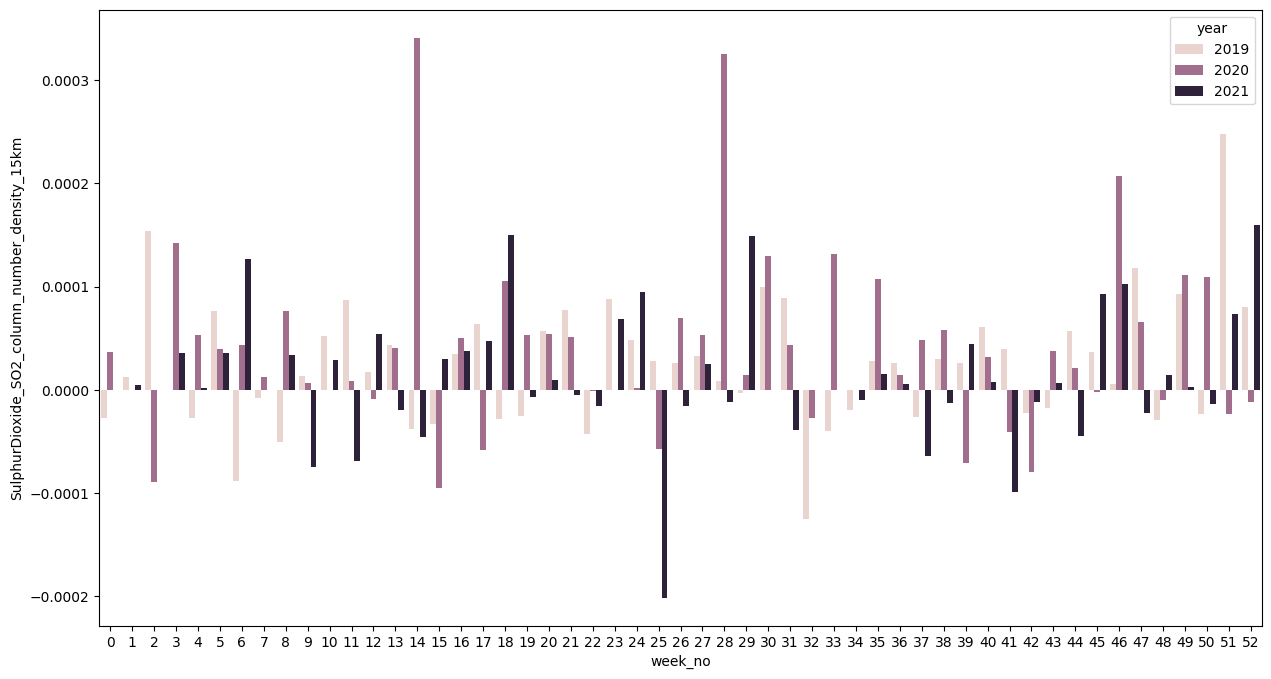

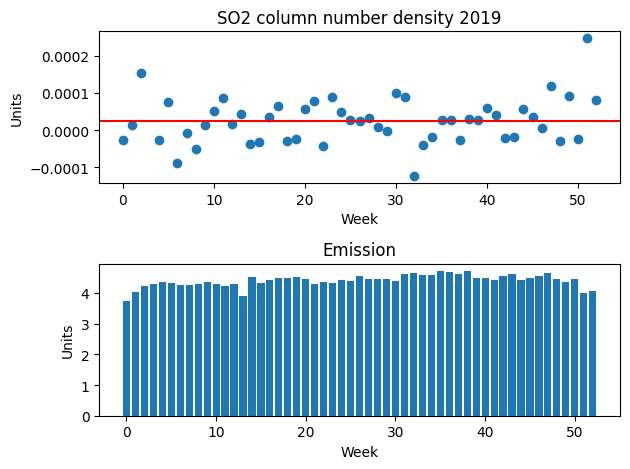

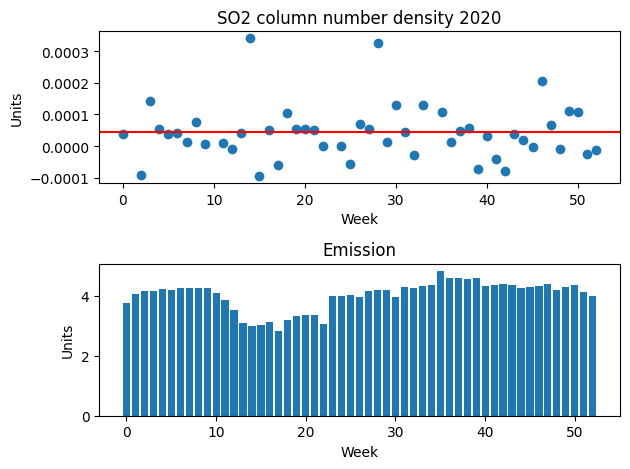

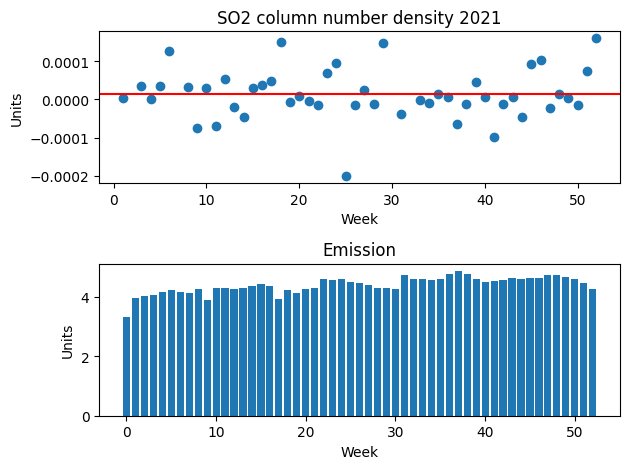

In [15]:
# THIS TYPE OF PLOT SHOWING DISTRIBUTION THEREFORE WE SHALL USE MEAN() STRATEGY

import matplotlib.pyplot as plt
import seaborn as sns

y_axis_inspect = 'SulphurDioxide_SO2_column_number_density_15km'
x_axis_inspect = 'week_no'

plt.figure(figsize=(15,8))
sns.barplot(data=a, x=x_axis_inspect, y=y_axis_inspect, hue='year')
plt.show()

plt.subplot(211)
plt.scatter(x=x_axis_inspect, y=y_axis_inspect, data=a[a['year'] == 2019])
plt.axhline(y=a[a['year'] == 2019][y_axis_inspect].mean(), color='red')
plt.title('SO2 column number density 2019')
plt.xlabel('Week')
plt.ylabel('Units')
plt.subplot(212)
plt.bar(x=x_axis_inspect, height='emission', data=a[a['year'] == 2019])
plt.title('Emission')
plt.xlabel('Week')
plt.ylabel('Units')
plt.tight_layout()
plt.show()

plt.subplot(211)
plt.scatter(x=x_axis_inspect, y=y_axis_inspect, data=a[a['year'] == 2020])
plt.axhline(y=a[a['year'] == 2020][y_axis_inspect].mean(), color='red')
plt.title('SO2 column number density 2020')
plt.xlabel('Week')
plt.ylabel('Units')
plt.subplot(212)
plt.bar(x=x_axis_inspect, height='emission', data=a[a['year'] == 2020])
plt.title('Emission')
plt.xlabel('Week')
plt.ylabel('Units')
plt.tight_layout()
plt.show()

plt.subplot(211)
plt.scatter(x=x_axis_inspect, y=y_axis_inspect, data=a[a['year'] == 2021])
plt.axhline(y=a[a['year'] == 2021][y_axis_inspect].mean(), color='red')
plt.title('SO2 column number density 2021')
plt.xlabel('Week')
plt.ylabel('Units')
plt.subplot(212)
plt.bar(x=x_axis_inspect, height='emission', data=a[a['year'] == 2021])
plt.title('Emission')
plt.xlabel('Week')
plt.ylabel('Units')
plt.tight_layout()
plt.show()



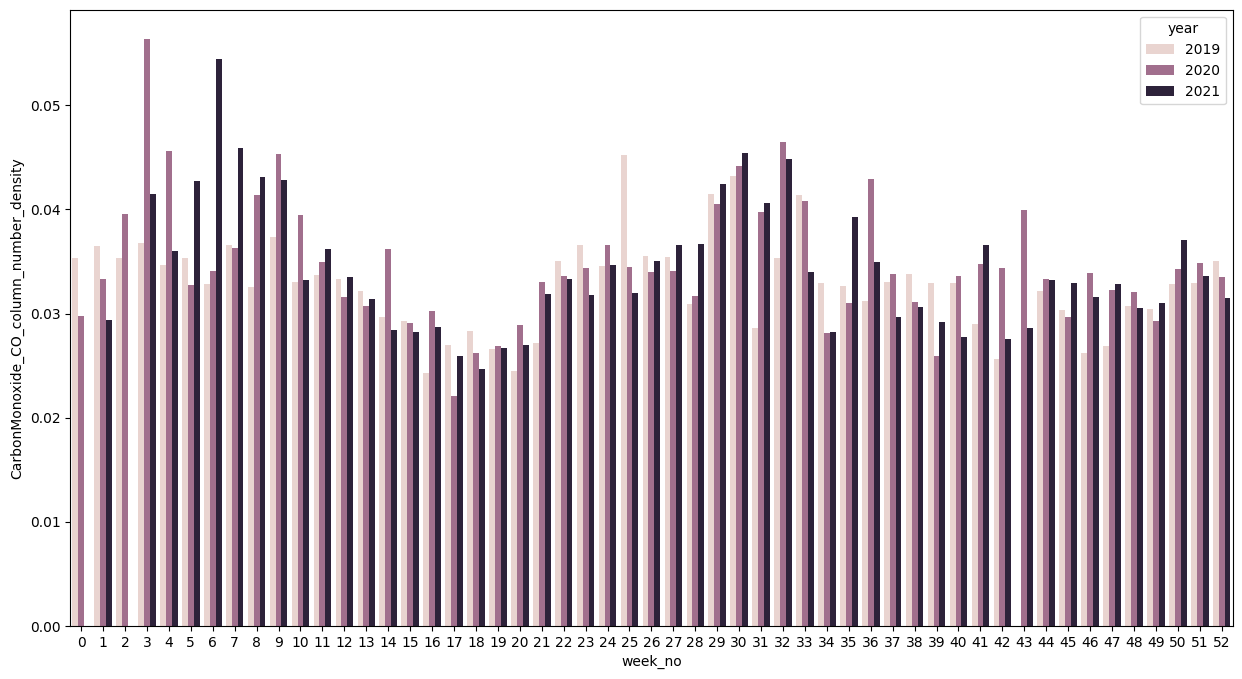

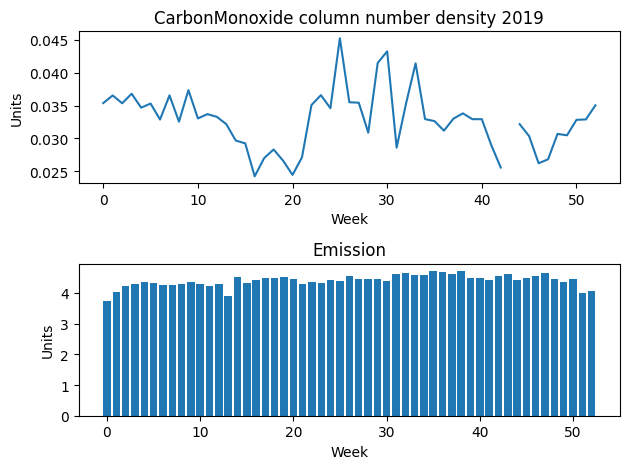

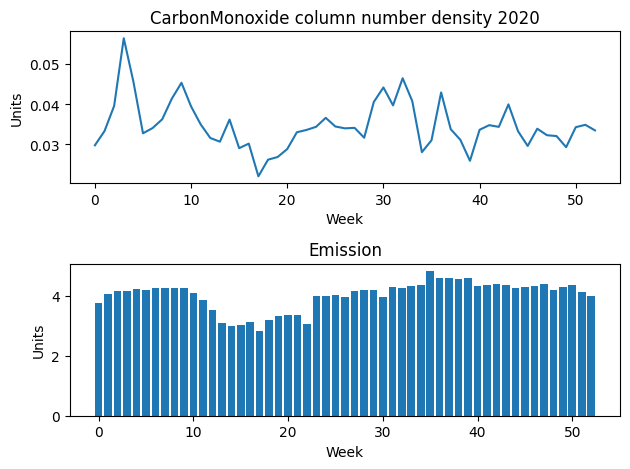

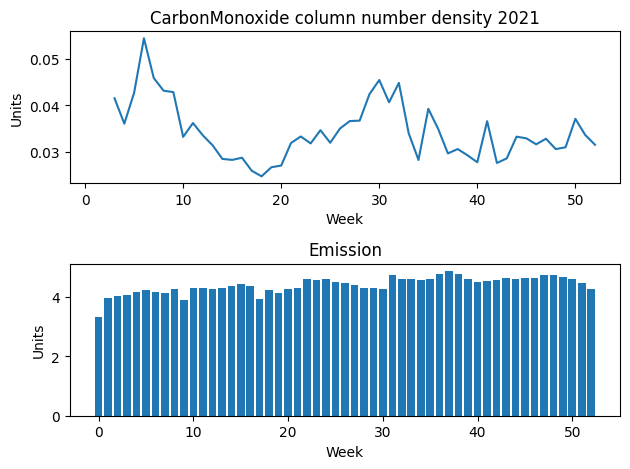

In [16]:
# THIS TYPE OF PLOT TRENDLINE THEREFORE WE SHALL USE INTERPOLATE() STRATEGY

y_axis_inspect = 'CarbonMonoxide_CO_column_number_density'
x_axis_inspect = 'week_no'

plt.figure(figsize=(15,8))
sns.barplot(data=a, x=x_axis_inspect, y=y_axis_inspect, hue='year')
plt.show()


plt.subplot(211)
plt.plot(x_axis_inspect, y_axis_inspect, data=a[a['year'] == 2019])
plt.title('CarbonMonoxide column number density 2019')
plt.xlabel('Week')
plt.ylabel('Units')
plt.subplot(212)
plt.bar(x=x_axis_inspect, height='emission', data=a[a['year'] == 2019])
plt.title('Emission')
plt.xlabel('Week')
plt.ylabel('Units')
plt.tight_layout()
plt.show()

plt.subplot(211)
plt.plot(x_axis_inspect, y_axis_inspect, data=a[a['year'] == 2020])
plt.title('CarbonMonoxide column number density 2020')
plt.xlabel('Week')
plt.ylabel('Units')
plt.subplot(212)
plt.bar(x=x_axis_inspect, height='emission', data=a[a['year'] == 2020])
plt.title('Emission')
plt.xlabel('Week')
plt.ylabel('Units')
plt.tight_layout()
plt.show()

plt.subplot(211)
plt.plot(x_axis_inspect, y_axis_inspect, data=a[a['year'] == 2021])
plt.title('CarbonMonoxide column number density 2021')
plt.xlabel('Week')
plt.ylabel('Units')
plt.subplot(212)
plt.bar(x=x_axis_inspect, height='emission', data=a[a['year'] == 2021])
plt.title('Emission')
plt.xlabel('Week')
plt.ylabel('Units')
plt.tight_layout()
plt.show()

#### REMARKS:
Finally, after checking all available features, the strategies for each features are as follow:
1. SulphurDioxide_SO2_slant_column_number_density = mean()
2. SulphurDioxide_solar_azimuth_angle = interpolate()
3. SulphurDioxide_SO2_column_number_density_15km = mean()
4. CarbonMonoxide_CO_column_number_density = interpolate()
5. CarbonMonoxide_H2O_column_number_density  = interpolate()
6. NitrogenDioxide_absorbing_aerosol_index = interpolate()
7. NitrogenDioxide_cloud_fraction = interpolate()
8. NitrogenDioxide_solar_azimuth_angle = interpolate()
9. Formaldehyde_tropospheric_HCHO_column_number_density = mean()
10. Formaldehyde_tropospheric_HCHO_column_number_density_amf = interpolate()
11. Formaldehyde_HCHO_slant_column_number_density = mean()
12. Formaldehyde_solar_azimuth_angle = interpolate()
13. UvAerosolLayerHeight_aerosol_optical_depth DROP ALL because most data values are empty
14. UvAerosolLayerHeight_sensor_azimuth_angle DROP ALL because most data values are empty
15. Cloud_surface_albedo = interpolate()

NOTE: When checking features 13 and 14 we found out that most data values are empty and therefore had to be dropped

In [17]:
emission.drop(columns=['UvAerosolLayerHeight_aerosol_optical_depth', 'UvAerosolLayerHeight_sensor_azimuth_angle'],
              inplace=True)
emission_dirty = emission.copy()

emission

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission
0,-0.510,29.290,2019,0,-0.000065,-130.050797,-0.000027,0.035370,1589.024536,NaN,NaN,NaN,0.000117,0.863230,0.000038,-130.050797,0.272292,3.750994
1,-0.510,29.290,2019,1,0.000014,-140.874435,0.000012,0.036526,1772.574405,-1.935386,0.067038,-138.343908,0.000170,1.172826,0.000143,-141.814827,0.256830,4.025176
2,-0.510,29.290,2019,2,0.000385,-150.191757,0.000154,0.035338,2703.236800,-2.754374,0.072135,-150.191757,0.000080,1.175467,0.000019,-135.667160,0.251101,4.231381
3,-0.510,29.290,2019,3,NaN,NaN,NaN,0.036790,2076.073332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.262043,4.305286
4,-0.510,29.290,2019,4,-0.000048,-137.409159,-0.000028,0.034675,2053.608490,-1.450563,0.049393,-136.257947,0.000269,0.869081,0.000146,-134.826557,0.235847,4.347317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79018,-3.299,30.301,2021,48,0.000340,-140.821274,0.000131,0.026488,1999.322864,-0.728791,0.152581,-130.881374,0.000064,1.712300,0.000054,-130.856579,0.304797,29.404171
79019,-3.299,30.301,2021,49,0.000063,-131.114411,0.000030,0.026049,1887.259212,-1.213713,0.101535,-128.938451,0.000101,1.686760,0.000097,-128.938451,0.314015,29.186497
79020,-3.299,30.301,2021,50,NaN,NaN,NaN,0.030098,1967.424136,-0.366031,0.187802,-128.051809,-0.000069,1.304604,-0.000145,-128.066071,0.288058,29.131205
79021,-3.299,30.301,2021,51,-0.000028,-129.573396,-0.000015,0.031012,3394.020508,-0.596050,0.045697,-129.573396,0.000080,1.222815,0.000042,-129.573396,0.274047,28.125792


In [18]:
mem = 0
mean_list = ['SulphurDioxide_SO2_slant_column_number_density',
             'SulphurDioxide_SO2_column_number_density_15km',
             'Formaldehyde_tropospheric_HCHO_column_number_density',
             'Formaldehyde_HCHO_slant_column_number_density']
interpolate_list = ['SulphurDioxide_solar_azimuth_angle',
                    'CarbonMonoxide_CO_column_number_density',
                    'CarbonMonoxide_H2O_column_number_density',
                    'NitrogenDioxide_absorbing_aerosol_index',
                    'NitrogenDioxide_cloud_fraction',
                    'NitrogenDioxide_solar_azimuth_angle',
                    'Formaldehyde_tropospheric_HCHO_column_number_density_amf',
                    'Formaldehyde_solar_azimuth_angle',
                    'Cloud_surface_albedo']


for k, v in emission['latitude'].items():
    if v != mem:
        emission.loc[(emission['latitude'] == v), mean_list] = emission.loc[(emission['latitude'] == v), mean_list].fillna(value=emission.loc[(emission['latitude'] == v), mean_list].median())
        # emission.loc[(emission['latitude'] == v), mean_list] = emission.loc[(emission['latitude'] == v), mean_list].fillna(method='ffil')
        mem = v
    elif v == mem:
        mem = v

mem = 0
for k, v in emission['latitude'].items():
    if v != mem:
        emission.loc[(emission['latitude'] == v), interpolate_list] = emission.loc[(emission['latitude'] == v), interpolate_list].interpolate(method='linear', 
                                                                                limit_direction='both')
        mem = v
    elif v == mem:
        mem = v

emission

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission
0,-0.510,29.290,2019,0,-0.000065,-130.050797,-0.000027,0.035370,1589.024536,-1.935386,0.067038,-138.343908,0.000117,0.863230,0.000038,-130.050797,0.272292,3.750994
1,-0.510,29.290,2019,1,0.000014,-140.874435,0.000012,0.036526,1772.574405,-1.935386,0.067038,-138.343908,0.000170,1.172826,0.000143,-141.814827,0.256830,4.025176
2,-0.510,29.290,2019,2,0.000385,-150.191757,0.000154,0.035338,2703.236800,-2.754374,0.072135,-150.191757,0.000080,1.175467,0.000019,-135.667160,0.251101,4.231381
3,-0.510,29.290,2019,3,0.000058,-143.800458,0.000025,0.036790,2076.073332,-2.102468,0.060764,-143.224852,0.000122,1.022274,0.000082,-135.246858,0.262043,4.305286
4,-0.510,29.290,2019,4,-0.000048,-137.409159,-0.000028,0.034675,2053.608490,-1.450563,0.049393,-136.257947,0.000269,0.869081,0.000146,-134.826557,0.235847,4.347317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79018,-3.299,30.301,2021,48,0.000340,-140.821274,0.000131,0.026488,1999.322864,-0.728791,0.152581,-130.881374,0.000064,1.712300,0.000054,-130.856579,0.304797,29.404171
79019,-3.299,30.301,2021,49,0.000063,-131.114411,0.000030,0.026049,1887.259212,-1.213713,0.101535,-128.938451,0.000101,1.686760,0.000097,-128.938451,0.314015,29.186497
79020,-3.299,30.301,2021,50,-0.000012,-130.343903,0.000005,0.030098,1967.424136,-0.366031,0.187802,-128.051809,-0.000069,1.304604,-0.000145,-128.066071,0.288058,29.131205
79021,-3.299,30.301,2021,51,-0.000028,-129.573396,-0.000015,0.031012,3394.020508,-0.596050,0.045697,-129.573396,0.000080,1.222815,0.000042,-129.573396,0.274047,28.125792


In [19]:
emission.isnull().sum()

latitude                                                      0
longitude                                                     0
year                                                          0
week_no                                                       0
SulphurDioxide_SO2_slant_column_number_density              477
SulphurDioxide_solar_azimuth_angle                          477
SulphurDioxide_SO2_column_number_density_15km               477
CarbonMonoxide_CO_column_number_density                     477
CarbonMonoxide_H2O_column_number_density                    477
NitrogenDioxide_absorbing_aerosol_index                     477
NitrogenDioxide_cloud_fraction                              477
NitrogenDioxide_solar_azimuth_angle                         477
Formaldehyde_tropospheric_HCHO_column_number_density        477
Formaldehyde_tropospheric_HCHO_column_number_density_amf    477
Formaldehyde_HCHO_slant_column_number_density               477
Formaldehyde_solar_azimuth_angle        

#### REMARKS:
Surprisingly we still have several `null` data. After checking the data thoroughly, we can pinpoint the remaining `null` and actually found that there are 3 coordinates that actually missing all data in all features, so we will eliminate these coordinates.

In [20]:
great = emission[emission['Formaldehyde_tropospheric_HCHO_column_number_density_amf'].isnull()]
great = great.groupby('latitude')['week_no'].apply(lambda x: x) 

clown = []
tem = 0
for k, v in great.items():
    if tem != k[0]:
        clown.append(k[0])
        tem = k[0]
    elif tem == k[0]:
        tem = k[0]

print(clown)

[-1.53, -1.41, -1.244]


In [21]:
clown_index = emission[emission['Formaldehyde_tropospheric_HCHO_column_number_density_amf'].isnull()].index
clown_index

emission = emission.drop(index=clown_index)
emission.reset_index(drop=True)

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission
0,-0.510,29.290,2019,0,-0.000065,-130.050797,-0.000027,0.035370,1589.024536,-1.935386,0.067038,-138.343908,0.000117,0.863230,0.000038,-130.050797,0.272292,3.750994
1,-0.510,29.290,2019,1,0.000014,-140.874435,0.000012,0.036526,1772.574405,-1.935386,0.067038,-138.343908,0.000170,1.172826,0.000143,-141.814827,0.256830,4.025176
2,-0.510,29.290,2019,2,0.000385,-150.191757,0.000154,0.035338,2703.236800,-2.754374,0.072135,-150.191757,0.000080,1.175467,0.000019,-135.667160,0.251101,4.231381
3,-0.510,29.290,2019,3,0.000058,-143.800458,0.000025,0.036790,2076.073332,-2.102468,0.060764,-143.224852,0.000122,1.022274,0.000082,-135.246858,0.262043,4.305286
4,-0.510,29.290,2019,4,-0.000048,-137.409159,-0.000028,0.034675,2053.608490,-1.450563,0.049393,-136.257947,0.000269,0.869081,0.000146,-134.826557,0.235847,4.347317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78541,-3.299,30.301,2021,48,0.000340,-140.821274,0.000131,0.026488,1999.322864,-0.728791,0.152581,-130.881374,0.000064,1.712300,0.000054,-130.856579,0.304797,29.404171
78542,-3.299,30.301,2021,49,0.000063,-131.114411,0.000030,0.026049,1887.259212,-1.213713,0.101535,-128.938451,0.000101,1.686760,0.000097,-128.938451,0.314015,29.186497
78543,-3.299,30.301,2021,50,-0.000012,-130.343903,0.000005,0.030098,1967.424136,-0.366031,0.187802,-128.051809,-0.000069,1.304604,-0.000145,-128.066071,0.288058,29.131205
78544,-3.299,30.301,2021,51,-0.000028,-129.573396,-0.000015,0.031012,3394.020508,-0.596050,0.045697,-129.573396,0.000080,1.222815,0.000042,-129.573396,0.274047,28.125792


In [22]:
emission.isnull().sum()

latitude                                                    0
longitude                                                   0
year                                                        0
week_no                                                     0
SulphurDioxide_SO2_slant_column_number_density              0
SulphurDioxide_solar_azimuth_angle                          0
SulphurDioxide_SO2_column_number_density_15km               0
CarbonMonoxide_CO_column_number_density                     0
CarbonMonoxide_H2O_column_number_density                    0
NitrogenDioxide_absorbing_aerosol_index                     0
NitrogenDioxide_cloud_fraction                              0
NitrogenDioxide_solar_azimuth_angle                         0
Formaldehyde_tropospheric_HCHO_column_number_density        0
Formaldehyde_tropospheric_HCHO_column_number_density_amf    0
Formaldehyde_HCHO_slant_column_number_density               0
Formaldehyde_solar_azimuth_angle                            0
Cloud_su

Next we will do Kolmogorov Smirnov test (KS-test), to check if we have made significant changes in original feature distribution per each coordinate. If the p-value below 0.05 then our technique in filling the NaNs would be considered as bad idea because we alter the distribution significantly. However, after we check the KS test result for all coordinates we found that 98 percent of the whole coordinates distributions are still intact, therefore we can consider this filling NaN strategy as acceptable.

In [23]:
emission_dirty = emission_dirty.drop(index=clown_index)
emission_dirty.reset_index(drop=True)
emission_dirty

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission
0,-0.510,29.290,2019,0,-0.000065,-130.050797,-0.000027,0.035370,1589.024536,NaN,NaN,NaN,0.000117,0.863230,0.000038,-130.050797,0.272292,3.750994
1,-0.510,29.290,2019,1,0.000014,-140.874435,0.000012,0.036526,1772.574405,-1.935386,0.067038,-138.343908,0.000170,1.172826,0.000143,-141.814827,0.256830,4.025176
2,-0.510,29.290,2019,2,0.000385,-150.191757,0.000154,0.035338,2703.236800,-2.754374,0.072135,-150.191757,0.000080,1.175467,0.000019,-135.667160,0.251101,4.231381
3,-0.510,29.290,2019,3,NaN,NaN,NaN,0.036790,2076.073332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.262043,4.305286
4,-0.510,29.290,2019,4,-0.000048,-137.409159,-0.000028,0.034675,2053.608490,-1.450563,0.049393,-136.257947,0.000269,0.869081,0.000146,-134.826557,0.235847,4.347317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79018,-3.299,30.301,2021,48,0.000340,-140.821274,0.000131,0.026488,1999.322864,-0.728791,0.152581,-130.881374,0.000064,1.712300,0.000054,-130.856579,0.304797,29.404171
79019,-3.299,30.301,2021,49,0.000063,-131.114411,0.000030,0.026049,1887.259212,-1.213713,0.101535,-128.938451,0.000101,1.686760,0.000097,-128.938451,0.314015,29.186497
79020,-3.299,30.301,2021,50,NaN,NaN,NaN,0.030098,1967.424136,-0.366031,0.187802,-128.051809,-0.000069,1.304604,-0.000145,-128.066071,0.288058,29.131205
79021,-3.299,30.301,2021,51,-0.000028,-129.573396,-0.000015,0.031012,3394.020508,-0.596050,0.045697,-129.573396,0.000080,1.222815,0.000042,-129.573396,0.274047,28.125792


In [24]:
lat = emission.groupby('latitude')['week_no'].apply(lambda x: x) 
lat_list = []
temp = 0
for k, v in lat.items():
    if temp != k[0]:
        lat_list.append(k[0])
        temp = k[0]
    elif temp == k[0]:
        temp = k[0]

print(lat_list)
print(len(lat_list))

[-3.299, -3.287, -3.174, -3.161, -3.153, -3.138, -3.136, -3.133, -3.099, -3.095, -3.054, -3.047, -3.032, -3.028, -3.025, -3.023, -3.016, -2.999, -2.986, -2.985, -2.979, -2.972, -2.97, -2.959, -2.958, -2.955, -2.946, -2.944, -2.939, -2.935, -2.931, -2.929, -2.924, -2.922, -2.902, -2.9, -2.899, -2.898, -2.896, -2.883, -2.879, -2.86, -2.859, -2.858, -2.855, -2.853, -2.851, -2.846, -2.842, -2.841, -2.839, -2.836, -2.834, -2.828, -2.821, -2.82, -2.819, -2.818, -2.817, -2.815, -2.812, -2.794, -2.783, -2.772, -2.771, -2.77, -2.766, -2.764, -2.763, -2.761, -2.757, -2.752, -2.751, -2.74, -2.734, -2.726, -2.721, -2.719, -2.712, -2.71, -2.7, -2.697, -2.696, -2.693, -2.689, -2.676, -2.673, -2.662, -2.656, -2.655, -2.652, -2.649, -2.643, -2.64, -2.638, -2.623, -2.61, -2.602, -2.599, -2.595, -2.589, -2.588, -2.583, -2.571, -2.561, -2.555, -2.548, -2.539, -2.522, -2.521, -2.517, -2.496, -2.491, -2.489, -2.484, -2.479, -2.466, -2.451, -2.447, -2.443, -2.441, -2.44, -2.436, -2.432, -2.431, -2.427, -2.4

In [25]:
from scipy.stats import ks_2samp
global_good = 0
global_bad = 0

for val in range(len(lat_list)):
    print(f'Now testing sample no {val}, that is latitude: {lat_list[val]}')
    good = 0
    bad = 0
    for i in emission.columns:
        original = emission_dirty.loc[(emission_dirty['latitude'] == lat_list[val]), i].dropna()
        filled = emission.loc[(emission_dirty['latitude'] == lat_list[val]), i]

        statistic, p_value = ks_2samp(original, filled)
        # print(f'Test for column: {i}, resulting p-value:{p_value:.2f}')
        if p_value > 0.05:
            global_good += 1
            good += 1
            # print(f'Test for column {i}: OK')
        else:
            global_bad += 1
            bad += 1
            # print('NOT OK')
    print(f'GOOD: {good}')
    print(f'BAD: {bad}')

print(f'final result Global Good: {global_good}, with percentage = {((global_good)/(global_bad+global_good))*100}')
print(f'final result Global Bad: {global_bad}, with percentage = {((global_bad)/(global_bad+global_good))*100}')

Now testing sample no 0, that is latitude: -3.299
GOOD: 18
BAD: 0
Now testing sample no 1, that is latitude: -3.287
GOOD: 18
BAD: 0
Now testing sample no 2, that is latitude: -3.174
GOOD: 18
BAD: 0
Now testing sample no 3, that is latitude: -3.161
GOOD: 18
BAD: 0
Now testing sample no 4, that is latitude: -3.153
GOOD: 18
BAD: 0
Now testing sample no 5, that is latitude: -3.138
GOOD: 18
BAD: 0
Now testing sample no 6, that is latitude: -3.136
GOOD: 18
BAD: 0
Now testing sample no 7, that is latitude: -3.133
GOOD: 18
BAD: 0
Now testing sample no 8, that is latitude: -3.099
GOOD: 18
BAD: 0
Now testing sample no 9, that is latitude: -3.095
GOOD: 18
BAD: 0
Now testing sample no 10, that is latitude: -3.054
GOOD: 18
BAD: 0
Now testing sample no 11, that is latitude: -3.047
GOOD: 18
BAD: 0
Now testing sample no 12, that is latitude: -3.032
GOOD: 18
BAD: 0
Now testing sample no 13, that is latitude: -3.028
GOOD: 18
BAD: 0
Now testing sample no 14, that is latitude: -3.025
GOOD: 18
BAD: 0
Now t

In [26]:
emission_b = emission.copy()
emission_b

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission
0,-0.510,29.290,2019,0,-0.000065,-130.050797,-0.000027,0.035370,1589.024536,-1.935386,0.067038,-138.343908,0.000117,0.863230,0.000038,-130.050797,0.272292,3.750994
1,-0.510,29.290,2019,1,0.000014,-140.874435,0.000012,0.036526,1772.574405,-1.935386,0.067038,-138.343908,0.000170,1.172826,0.000143,-141.814827,0.256830,4.025176
2,-0.510,29.290,2019,2,0.000385,-150.191757,0.000154,0.035338,2703.236800,-2.754374,0.072135,-150.191757,0.000080,1.175467,0.000019,-135.667160,0.251101,4.231381
3,-0.510,29.290,2019,3,0.000058,-143.800458,0.000025,0.036790,2076.073332,-2.102468,0.060764,-143.224852,0.000122,1.022274,0.000082,-135.246858,0.262043,4.305286
4,-0.510,29.290,2019,4,-0.000048,-137.409159,-0.000028,0.034675,2053.608490,-1.450563,0.049393,-136.257947,0.000269,0.869081,0.000146,-134.826557,0.235847,4.347317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79018,-3.299,30.301,2021,48,0.000340,-140.821274,0.000131,0.026488,1999.322864,-0.728791,0.152581,-130.881374,0.000064,1.712300,0.000054,-130.856579,0.304797,29.404171
79019,-3.299,30.301,2021,49,0.000063,-131.114411,0.000030,0.026049,1887.259212,-1.213713,0.101535,-128.938451,0.000101,1.686760,0.000097,-128.938451,0.314015,29.186497
79020,-3.299,30.301,2021,50,-0.000012,-130.343903,0.000005,0.030098,1967.424136,-0.366031,0.187802,-128.051809,-0.000069,1.304604,-0.000145,-128.066071,0.288058,29.131205
79021,-3.299,30.301,2021,51,-0.000028,-129.573396,-0.000015,0.031012,3394.020508,-0.596050,0.045697,-129.573396,0.000080,1.222815,0.000042,-129.573396,0.274047,28.125792


##### EMISSION VS YEARS
For clarity we will see the visualization of CO2 Emission during 2019, 2020 and 2021. Here we note that the emission is lower in the year 2020, presumably because lots of activities were being halted due to COVID Pandemic situation, and gradually increasing again in 2021.

In [27]:
import folium
from folium.plugins import HeatMapWithTime

chrono = emission.copy()
# chrono['week_no'] = chrono['week_no'].replace(0, 1)
chrono['date'] = pd.to_datetime(chrono['year'].astype(str) + chrono['week_no'].astype(str) + '1', format='%G%V%u')
chrono

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission,date
0,-0.510,29.290,2019,0,-0.000065,-130.050797,-0.000027,0.035370,1589.024536,-1.935386,0.067038,-138.343908,0.000117,0.863230,0.000038,-130.050797,0.272292,3.750994,2018-12-24
1,-0.510,29.290,2019,1,0.000014,-140.874435,0.000012,0.036526,1772.574405,-1.935386,0.067038,-138.343908,0.000170,1.172826,0.000143,-141.814827,0.256830,4.025176,2018-12-31
2,-0.510,29.290,2019,2,0.000385,-150.191757,0.000154,0.035338,2703.236800,-2.754374,0.072135,-150.191757,0.000080,1.175467,0.000019,-135.667160,0.251101,4.231381,2019-01-07
3,-0.510,29.290,2019,3,0.000058,-143.800458,0.000025,0.036790,2076.073332,-2.102468,0.060764,-143.224852,0.000122,1.022274,0.000082,-135.246858,0.262043,4.305286,2019-01-14
4,-0.510,29.290,2019,4,-0.000048,-137.409159,-0.000028,0.034675,2053.608490,-1.450563,0.049393,-136.257947,0.000269,0.869081,0.000146,-134.826557,0.235847,4.347317,2019-01-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79018,-3.299,30.301,2021,48,0.000340,-140.821274,0.000131,0.026488,1999.322864,-0.728791,0.152581,-130.881374,0.000064,1.712300,0.000054,-130.856579,0.304797,29.404171,2021-11-29
79019,-3.299,30.301,2021,49,0.000063,-131.114411,0.000030,0.026049,1887.259212,-1.213713,0.101535,-128.938451,0.000101,1.686760,0.000097,-128.938451,0.314015,29.186497,2021-12-06
79020,-3.299,30.301,2021,50,-0.000012,-130.343903,0.000005,0.030098,1967.424136,-0.366031,0.187802,-128.051809,-0.000069,1.304604,-0.000145,-128.066071,0.288058,29.131205,2021-12-13
79021,-3.299,30.301,2021,51,-0.000028,-129.573396,-0.000015,0.031012,3394.020508,-0.596050,0.045697,-129.573396,0.000080,1.222815,0.000042,-129.573396,0.274047,28.125792,2021-12-20


In [28]:
from sklearn.preprocessing import MinMaxScaler

preproc = MinMaxScaler()

chrono_2019 = chrono.loc[chrono['year'] == 2019]
chrono_2019[['emission']] = preproc.fit_transform(chrono_2019[['emission']])
chrono_2019

C:\Users\anton\AppData\Local\Temp\ipykernel_19472\377450324.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chrono_2019[['emission']] = preproc.fit_transform(chrono_2019[['emission']])


,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission,date
0,-0.510,29.290,2019,0,-0.000065,-130.050797,-0.000027,0.035370,1589.024536,-1.935386,0.067038,-138.343908,0.000117,0.863230,0.000038,-130.050797,0.272292,0.001184,2018-12-24
1,-0.510,29.290,2019,1,0.000014,-140.874435,0.000012,0.036526,1772.574405,-1.935386,0.067038,-138.343908,0.000170,1.172826,0.000143,-141.814827,0.256830,0.001271,2018-12-31
2,-0.510,29.290,2019,2,0.000385,-150.191757,0.000154,0.035338,2703.236800,-2.754374,0.072135,-150.191757,0.000080,1.175467,0.000019,-135.667160,0.251101,0.001336,2019-01-07
3,-0.510,29.290,2019,3,0.000058,-143.800458,0.000025,0.036790,2076.073332,-2.102468,0.060764,-143.224852,0.000122,1.022274,0.000082,-135.246858,0.262043,0.001359,2019-01-14
4,-0.510,29.290,2019,4,-0.000048,-137.409159,-0.000028,0.034675,2053.608490,-1.450563,0.049393,-136.257947,0.000269,0.869081,0.000146,-134.826557,0.235847,0.001372,2019-01-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78912,-3.299,30.301,2019,48,0.000264,-129.415112,0.000120,0.028752,2175.944939,-2.567476,0.130772,-129.415112,-0.000017,1.669733,-0.000081,-126.908501,0.273427,0.009453,2019-11-25
78913,-3.299,30.301,2019,49,-0.000015,-137.883987,-0.000005,0.026378,1908.626800,-2.337782,0.063200,-137.928497,0.000017,1.228177,-0.000046,-139.273144,0.283932,0.009327,2019-12-02
78914,-3.299,30.301,2019,50,-0.000221,-139.888214,-0.000084,0.030168,2220.846171,-2.105925,0.031600,-134.048003,0.000172,1.510383,0.000221,-139.154436,0.309550,0.009452,2019-12-09
78915,-3.299,30.301,2019,51,-0.000383,-130.167509,-0.000182,0.031805,2280.348241,-1.874067,0.000000,-130.167509,0.000216,0.917294,0.000126,-132.041075,0.270928,0.008639,2019-12-16


In [29]:
# Group data by time
grouped = chrono_2019.groupby('date')

# Prepare heatmap data: list of [ [lat, lon, intensity], ... ] per time step
heat_data = []
time_index = []

for time, group in grouped:
    points = group[['latitude', 'longitude', 'emission']].values.tolist()
    heat_data.append(points)
    time_index.append(time.strftime('%Y-%m-%d %H:%M:%S'))

# Initialize the map centered around the data
m = folium.Map(location=[chrono_2019['latitude'].mean(), chrono_2019['longitude'].mean()])

# Create the timestamped heatmap
HeatMapWithTime(
    data=heat_data,
    index=time_index,
    auto_play=True,
    max_opacity=1.0,
    radius=20
).add_to(m)

m

In [30]:
chrono_2020 = chrono.loc[chrono['year'] == 2020]
chrono_2020[['emission']] = preproc.fit_transform(chrono_2020[['emission']])
chrono_2020

C:\Users\anton\AppData\Local\Temp\ipykernel_19472\1331870158.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chrono_2020[['emission']] = preproc.fit_transform(chrono_2020[['emission']])


,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission,date
53,-0.510,29.290,2020,0,0.000073,-134.074249,0.000037,0.029794,2627.004946,-1.841975,0.091368,-134.074249,0.000251,0.919265,0.000155,-140.310822,0.283116,0.001221,2019-12-23
54,-0.510,29.290,2020,1,0.000058,-141.641499,0.000025,0.033327,2756.260974,-1.792131,0.077881,-141.641499,0.000122,0.974046,0.000082,-144.759785,0.317732,0.001319,2019-12-30
55,-0.510,29.290,2020,2,-0.000231,-149.208748,-0.000090,0.039572,2109.154668,-1.742287,0.064394,-149.208748,0.000313,1.028827,0.000254,-149.208748,0.265554,0.001352,2020-01-06
56,-0.510,29.290,2020,3,0.000331,-145.779449,0.000142,0.056396,4323.970215,-1.385194,0.112022,-145.779449,0.000005,0.742077,-0.000034,-140.966390,0.267030,0.001356,2020-01-13
57,-0.510,29.290,2020,4,0.000112,-133.768265,0.000053,0.045636,2217.837769,-1.572114,0.067644,-134.147659,-0.000063,1.665289,-0.000162,-133.768265,0.268983,0.001378,2020-01-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78965,-3.299,30.301,2020,48,0.000125,-136.418747,0.000056,0.028853,2054.887182,-2.968529,0.118807,-136.418747,0.000136,1.682876,0.000167,-136.418747,0.261608,0.008763,2020-11-23
78966,-3.299,30.301,2020,49,0.000031,-146.493896,0.000060,0.026532,1918.315449,-2.791375,0.120318,-135.735146,0.000529,1.182423,0.000556,-146.445962,0.276616,0.008658,2020-11-30
78967,-3.299,30.301,2020,50,-0.000149,-127.172714,-0.000062,0.028139,1828.489990,-2.614221,0.121829,-135.051544,0.000140,1.225507,0.000112,-127.172714,0.260574,0.008869,2020-12-07
78968,-3.299,30.301,2020,51,-0.000012,-128.243202,0.000005,0.033657,1833.157262,-2.437067,0.123340,-134.367943,-0.000027,1.574590,-0.000086,-141.522853,0.248484,0.008328,2020-12-14


In [31]:
# Group data by time
grouped = chrono_2020.groupby('date')

# Prepare heatmap data: list of [ [lat, lon, intensity], ... ] per time step
heat_data = []
time_index = []

for time, group in grouped:
    points = group[['latitude', 'longitude', 'emission']].values.tolist()
    heat_data.append(points)
    time_index.append(time.strftime('%Y-%m-%d %H:%M:%S'))

# Initialize the map centered around the data
m = folium.Map(location=[chrono_2020['latitude'].mean(), chrono_2020['longitude'].mean()])

# Create the timestamped heatmap
HeatMapWithTime(
    data=heat_data,
    index=time_index,
    auto_play=True,
    max_opacity=1.0,
    radius=20
).add_to(m)

m

In [32]:
chrono_2021 = chrono.loc[chrono['year'] == 2021]
chrono_2021[['emission']] = preproc.fit_transform(chrono_2021[['emission']])
chrono_2021

C:\Users\anton\AppData\Local\Temp\ipykernel_19472\4155460186.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chrono_2021[['emission']] = preproc.fit_transform(chrono_2021[['emission']])


,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission,date
106,-0.510,29.290,2021,0,0.000058,-139.340766,0.000025,0.031411,2493.554992,-2.782395,0.106141,-136.951114,0.000122,1.350120,0.000082,-136.511065,0.348412,0.001144,2020-12-28
107,-0.510,29.290,2021,1,0.000010,-142.884699,0.000005,0.029328,3325.736376,-3.207967,0.111586,-142.884699,0.000066,1.300194,0.000018,-137.236165,0.313980,0.001369,2021-01-04
108,-0.510,29.290,2021,2,0.000058,-145.135225,0.000025,0.035428,2780.808425,-2.993741,0.111934,-145.135225,0.000122,1.150611,0.000082,-140.966693,0.317191,0.001389,2021-01-11
109,-0.510,29.290,2021,3,0.000083,-147.385750,0.000035,0.041528,2235.880473,-2.779515,0.112282,-147.385750,0.000117,1.001029,0.000060,-144.697220,0.283179,0.001407,2021-01-18
110,-0.510,29.290,2021,4,-0.000020,-140.225195,0.000002,0.036051,2022.971317,-2.135162,0.082883,-140.225195,0.000085,1.111039,0.000043,-140.225195,0.268286,0.001434,2021-01-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79018,-3.299,30.301,2021,48,0.000340,-140.821274,0.000131,0.026488,1999.322864,-0.728791,0.152581,-130.881374,0.000064,1.712300,0.000054,-130.856579,0.304797,0.010135,2021-11-29
79019,-3.299,30.301,2021,49,0.000063,-131.114411,0.000030,0.026049,1887.259212,-1.213713,0.101535,-128.938451,0.000101,1.686760,0.000097,-128.938451,0.314015,0.010060,2021-12-06
79020,-3.299,30.301,2021,50,-0.000012,-130.343903,0.000005,0.030098,1967.424136,-0.366031,0.187802,-128.051809,-0.000069,1.304604,-0.000145,-128.066071,0.288058,0.010041,2021-12-13
79021,-3.299,30.301,2021,51,-0.000028,-129.573396,-0.000015,0.031012,3394.020508,-0.596050,0.045697,-129.573396,0.000080,1.222815,0.000042,-129.573396,0.274047,0.009694,2021-12-20


In [33]:
# Group data by time
grouped = chrono_2021.groupby('date')

# Prepare heatmap data: list of [ [lat, lon, intensity], ... ] per time step
heat_data = []
time_index = []

for time, group in grouped:
    points = group[['latitude', 'longitude', 'emission']].values.tolist()
    heat_data.append(points)
    time_index.append(time.strftime('%Y-%m-%d %H:%M:%S'))

# Initialize the map centered around the data
m = folium.Map(location=[chrono_2021['latitude'].mean(), chrono_2021['longitude'].mean()])

# Create the timestamped heatmap
HeatMapWithTime(
    data=heat_data,
    index=time_index,
    auto_play=True,
    max_opacity=1.0,
    radius=20
).add_to(m)

m

In [34]:
max_em = max(emission['emission'])
min_em = min(emission['emission'])

---
### B. MACHINE LEARNING MODELLING
Here we will do Machine Learning with 3 models: `LinearRegression`, `RandomForestRegressor`,`GradientBoostingRegressor`. From that 3 models we will choose the model that has best performance among all and will be used for data forecasting in `test.csv`

In [35]:
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler()
emission[emission.columns] = scale.fit_transform(emission[emission.columns])
emission

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission
0,1.0,0.321429,0.0,0.000000,0.160403,0.198167,0.394492,0.342267,0.147211,0.446512,0.087546,0.147745,0.347060,0.204184,0.455756,0.198421,0.354186,0.001184
1,1.0,0.321429,0.0,0.019231,0.175811,0.119422,0.406572,0.362480,0.167796,0.446512,0.087546,0.147745,0.379724,0.334051,0.525909,0.112954,0.332676,0.001271
2,1.0,0.321429,0.0,0.038462,0.248237,0.051637,0.449851,0.341707,0.272168,0.309462,0.094202,0.062520,0.324520,0.335159,0.443035,0.157618,0.324706,0.001336
3,1.0,0.321429,0.0,0.057692,0.184415,0.098135,0.410355,0.367103,0.201833,0.418552,0.079352,0.112635,0.350365,0.270899,0.485063,0.160671,0.339927,0.001359
4,1.0,0.321429,0.0,0.076923,0.163859,0.144633,0.394340,0.330122,0.199313,0.527642,0.064502,0.162750,0.441438,0.206639,0.527911,0.163725,0.303485,0.001372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79018,0.0,0.627421,1.0,0.923077,0.239425,0.119809,0.442826,0.186984,0.193225,0.648424,0.199257,0.201425,0.314528,0.560344,0.466195,0.192567,0.399406,0.009282
79019,0.0,0.627421,1.0,0.942308,0.185505,0.190429,0.412013,0.179319,0.180658,0.567277,0.132596,0.215401,0.337441,0.549631,0.494869,0.206503,0.412230,0.009214
79020,0.0,0.627421,1.0,0.961538,0.170752,0.196034,0.404237,0.250109,0.189648,0.709128,0.245253,0.221778,0.232179,0.389328,0.334041,0.212841,0.376120,0.009196
79021,0.0,0.627421,1.0,0.980769,0.167703,0.201640,0.398327,0.266078,0.349638,0.670637,0.059677,0.210833,0.324567,0.355020,0.458370,0.201890,0.356628,0.008879


In [36]:
y = emission['emission']
x = emission.drop(columns='emission')

In [37]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

##### MODELLING WITH LINEAR REGRESSION

In [38]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)
y_pred_lin = lin_reg.predict(x_test)
y_pred_lin

array([0.02313801, 0.02140983, 0.02628427, ..., 0.02494133, 0.0286623 ,
       0.02816447])

In [39]:
from sklearn.metrics import root_mean_squared_error

score_rmse_lin = root_mean_squared_error(y_test, y_pred_lin)
print(f'Score rmse LinearRegressor: {score_rmse_lin}')

Score rmse LinearRegressor: 0.045688757254507946


In [40]:
max_val = max(y_test)
min_val = min(y_test)
range_train = max_val - min_val

NRMSE_lin = (score_rmse_lin / range_train) * 100
print(f'min train value is: {min_val}')
print(f'max train value is: {max_val}')
print(f'NRMSE is: {NRMSE_lin:.2f}%')

min train value is: 0.0
max train value is: 0.955862518972349
NRMSE is: 4.78%


##### MODELLING WITH RANDOM FOREST REGRESSOR

In [41]:
from sklearn.ensemble import RandomForestRegressor

rff_rg = RandomForestRegressor(n_estimators=150, criterion='squared_error')
rff_rg.fit(x_train, y_train)
y_pred_rff = rff_rg.predict(x_test)
y_pred_rff

array([0.09724041, 0.00202857, 0.02653486, ..., 0.04110612, 0.00231549,
       0.03094853])

In [42]:
from sklearn.metrics import root_mean_squared_error

score_rmse_rff = root_mean_squared_error(y_test, y_pred_rff)
print(f'Score rmse: {score_rmse_rff}')

Score rmse: 0.005517216123023091


In [43]:
max_val = max(y_test)
min_val = min(y_test)
range_train = max_val - min_val

NRMSE_rff = (score_rmse_rff / range_train) * 100
print(f'min train value is: {min_val}')
print(f'max train value is: {max_val}')
print(f'NRMSE is: {NRMSE_rff:.2f}%')

min train value is: 0.0
max train value is: 0.955862518972349
NRMSE is: 0.58%


##### MODELLING WITH GRADIENT BOOSTING REGRESSOR

In [44]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_rg = GradientBoostingRegressor(n_estimators=150, criterion='squared_error')
gbr_rg.fit(x_train, y_train)
y_pred_gbr = gbr_rg.predict(x_test)
y_pred_gbr

array([0.07289653, 0.00229172, 0.03915469, ..., 0.02090852, 0.00387537,
       0.02446365])

In [45]:
score_rmse_gbr = root_mean_squared_error(y_test, y_pred_gbr)
print(f'Score rmse: {score_rmse_gbr}')

Score rmse: 0.018161475545912978


In [46]:
NRMSE_gbr = (score_rmse_gbr / range_train) * 100
print(f'min train value is: {min_val}')
print(f'max train value is: {max_val}')
print(f'NRMSE is: {NRMSE_gbr:.2f}%')

min train value is: 0.0
max train value is: 0.955862518972349
NRMSE is: 1.90%


---
### C. TEST THE BEST MODEL
After testing 3 model we can see that `RandomForestRegressor` perform better than the others, so we will pick that model and do the testing in `test.csv` file. Remember that we have to do the same data cleaning as with `train.csv` to make sure that they both have the same format, dimension and features.

In [71]:
test = pd.read_csv('test.csv')
test

,ID_LAT_LON_YEAR_WEEK,latitude,longitude,year,week_no,SulphurDioxide_SO2_column_number_density,SulphurDioxide_SO2_column_number_density_amf,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_cloud_fraction,SulphurDioxide_sensor_azimuth_angle,...,Cloud_cloud_top_pressure,Cloud_cloud_top_height,Cloud_cloud_base_pressure,Cloud_cloud_base_height,Cloud_cloud_optical_depth,Cloud_surface_albedo,Cloud_sensor_azimuth_angle,Cloud_sensor_zenith_angle,Cloud_solar_azimuth_angle,Cloud_solar_zenith_angle
0,ID_-0.510_29.290_2022_00,-0.510,29.290,2022,0,NaN,NaN,NaN,NaN,NaN,...,36022.027344,8472.313477,41047.937500,7472.313477,7.935617,0.240773,-100.113792,33.697044,-133.047546,33.779583
1,ID_-0.510_29.290_2022_01,-0.510,29.290,2022,1,0.000456,0.691164,0.000316,0.000000,76.239196,...,48539.737242,6476.147323,54915.708579,5476.147161,11.448437,0.293119,-30.510319,42.402593,-138.632822,31.012380
2,ID_-0.510_29.290_2022_02,-0.510,29.290,2022,2,0.000161,0.605107,0.000106,0.079870,-42.055341,...,34133.080469,8984.795703,39006.093750,7984.795703,10.753179,0.267130,39.087361,45.936480,-144.784988,26.743361
3,ID_-0.510_29.290_2022_03,-0.510,29.290,2022,3,0.000350,0.696917,0.000243,0.201028,72.169566,...,50854.991076,6014.724059,57646.368368,5014.724115,11.764556,0.304679,-24.465127,42.140419,-135.027891,29.604774
4,ID_-0.510_29.290_2022_04,-0.510,29.290,2022,4,-0.000317,0.580527,-0.000184,0.204352,76.190865,...,46594.685145,6849.280477,52896.541873,5849.280394,13.065317,0.284221,-12.907850,30.122641,-135.500119,26.276807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,ID_-3.299_30.301_2022_44,-3.299,30.301,2022,44,-0.000618,0.745549,-0.000461,0.234492,72.306198,...,48839.430415,6260.120033,55483.459980,5260.120056,30.398508,0.180046,-25.528588,45.284576,-116.521412,29.992562
24349,ID_-3.299_30.301_2022_45,-3.299,30.301,2022,45,NaN,NaN,NaN,NaN,NaN,...,47042.694849,6678.843299,53589.917383,5678.951521,19.223844,0.177833,-13.380005,43.770351,-122.405759,29.017975
24350,ID_-3.299_30.301_2022_46,-3.299,30.301,2022,46,NaN,NaN,NaN,NaN,NaN,...,55337.148173,5336.282475,62646.761340,4336.282491,13.801194,0.219471,-5.072065,33.226455,-124.530639,30.187472
24351,ID_-3.299_30.301_2022_47,-3.299,30.301,2022,47,0.000071,1.003805,0.000077,0.205077,74.327427,...,44813.691428,7188.578533,50728.313991,6188.578464,27.887489,0.247275,-0.668714,45.885617,-129.006797,30.427455


In [72]:
test.drop(columns='ID_LAT_LON_YEAR_WEEK',
              inplace=True)

test.drop(columns=[title for title in test.columns if (title not in selected_feature)
                       and (title != 'latitude') and (title != 'longitude') and (title != 'week_no')],
              inplace=True)

test.drop(columns=['UvAerosolLayerHeight_aerosol_optical_depth', 'UvAerosolLayerHeight_sensor_azimuth_angle'],
              inplace=True)
test

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo
0,-0.510,29.290,2022,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.240773
1,-0.510,29.290,2022,1,0.000316,-140.529848,0.000157,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000123,0.957096,0.000058,-140.529848,0.293119
2,-0.510,29.290,2022,2,0.000106,-136.908976,0.000053,0.037795,2629.692089,-0.008104,0.036490,-131.658058,0.000277,0.764546,0.000151,-143.602313,0.267130
3,-0.510,29.290,2022,3,0.000243,-152.999440,0.000093,0.039743,1905.403107,-1.279531,0.134641,-152.999440,0.000151,0.935210,0.000078,-148.466265,0.304679
4,-0.510,29.290,2022,4,-0.000184,-135.794754,-0.000077,0.039232,1307.190702,NaN,NaN,NaN,0.000273,0.776969,0.000140,-142.256966,0.284221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,-3.299,30.301,2022,44,-0.000461,-123.965439,-0.000171,0.034566,1745.198159,NaN,NaN,NaN,0.000246,0.936790,0.000167,-123.965439,0.180046
24349,-3.299,30.301,2022,45,NaN,NaN,NaN,0.038438,1699.572241,-1.289134,0.226918,-115.022250,NaN,NaN,NaN,NaN,0.177833
24350,-3.299,30.301,2022,46,NaN,NaN,NaN,0.033042,1655.505823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.219471
24351,-3.299,30.301,2022,47,0.000077,-131.809054,0.000037,0.030662,1689.421079,-1.786733,0.138160,-131.809054,0.000002,1.424614,-0.000063,-131.809054,0.247275


In [73]:
mem = 0

for k, v in test['latitude'].items():
    if v != mem:
        test.loc[(test['latitude'] == v), mean_list] = test.loc[(test['latitude'] == v), mean_list].fillna(value=test.loc[(test['latitude'] == v), mean_list].median())
        mem = v
    elif v == mem:
        mem = v

mem = 0
for k, v in test['latitude'].items():
    if v != mem:
        test.loc[(test['latitude'] == v), interpolate_list] = test.loc[(test['latitude'] == v), interpolate_list].interpolate(method='linear',
                                                                                limit_direction='both')
        mem = v
    elif v == mem:
        mem = v

test

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo
0,-0.510,29.290,2022,0,-0.000017,-140.529848,-0.000001,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000135,0.957096,0.000097,-140.529848,0.240773
1,-0.510,29.290,2022,1,0.000316,-140.529848,0.000157,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000123,0.957096,0.000058,-140.529848,0.293119
2,-0.510,29.290,2022,2,0.000106,-136.908976,0.000053,0.037795,2629.692089,-0.008104,0.036490,-131.658058,0.000277,0.764546,0.000151,-143.602313,0.267130
3,-0.510,29.290,2022,3,0.000243,-152.999440,0.000093,0.039743,1905.403107,-1.279531,0.134641,-152.999440,0.000151,0.935210,0.000078,-148.466265,0.304679
4,-0.510,29.290,2022,4,-0.000184,-135.794754,-0.000077,0.039232,1307.190702,-1.003091,0.125805,-148.414378,0.000273,0.776969,0.000140,-142.256966,0.284221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,-3.299,30.301,2022,44,-0.000461,-123.965439,-0.000171,0.034566,1745.198159,-1.261533,0.198474,-113.995392,0.000246,0.936790,0.000167,-123.965439,0.180046
24349,-3.299,30.301,2022,45,-0.000029,-126.579977,-0.000010,0.038438,1699.572241,-1.289134,0.226918,-115.022250,0.000119,1.099398,0.000081,-126.579977,0.177833
24350,-3.299,30.301,2022,46,-0.000029,-129.194516,-0.000010,0.033042,1655.505823,-1.537933,0.182539,-123.415652,0.000119,1.262006,0.000081,-129.194516,0.219471
24351,-3.299,30.301,2022,47,0.000077,-131.809054,0.000037,0.030662,1689.421079,-1.786733,0.138160,-131.809054,0.000002,1.424614,-0.000063,-131.809054,0.247275


In [74]:
great_test = test[test['Formaldehyde_tropospheric_HCHO_column_number_density_amf'].isnull()]
great_test = great_test.groupby('latitude')['week_no'].apply(lambda x: x)

clown_test = []
tem = 0
for k, v in great_test.items():
    if tem != k[0]:
        clown_test.append(k[0])
        tem = k[0]
    elif tem == k[0]:
        tem = k[0]

print(clown_test)

[-1.53, -1.41, -1.244]


In [75]:
clown_index_test = test[test['Formaldehyde_tropospheric_HCHO_column_number_density_amf'].isnull()].index
clown_index_test

test = test.drop(index=clown_index_test)
test.reset_index(drop=True)

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo
0,-0.510,29.290,2022,0,-0.000017,-140.529848,-0.000001,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000135,0.957096,0.000097,-140.529848,0.240773
1,-0.510,29.290,2022,1,0.000316,-140.529848,0.000157,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000123,0.957096,0.000058,-140.529848,0.293119
2,-0.510,29.290,2022,2,0.000106,-136.908976,0.000053,0.037795,2629.692089,-0.008104,0.036490,-131.658058,0.000277,0.764546,0.000151,-143.602313,0.267130
3,-0.510,29.290,2022,3,0.000243,-152.999440,0.000093,0.039743,1905.403107,-1.279531,0.134641,-152.999440,0.000151,0.935210,0.000078,-148.466265,0.304679
4,-0.510,29.290,2022,4,-0.000184,-135.794754,-0.000077,0.039232,1307.190702,-1.003091,0.125805,-148.414378,0.000273,0.776969,0.000140,-142.256966,0.284221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24201,-3.299,30.301,2022,44,-0.000461,-123.965439,-0.000171,0.034566,1745.198159,-1.261533,0.198474,-113.995392,0.000246,0.936790,0.000167,-123.965439,0.180046
24202,-3.299,30.301,2022,45,-0.000029,-126.579977,-0.000010,0.038438,1699.572241,-1.289134,0.226918,-115.022250,0.000119,1.099398,0.000081,-126.579977,0.177833
24203,-3.299,30.301,2022,46,-0.000029,-129.194516,-0.000010,0.033042,1655.505823,-1.537933,0.182539,-123.415652,0.000119,1.262006,0.000081,-129.194516,0.219471
24204,-3.299,30.301,2022,47,0.000077,-131.809054,0.000037,0.030662,1689.421079,-1.786733,0.138160,-131.809054,0.000002,1.424614,-0.000063,-131.809054,0.247275


In [76]:
import numpy as np

dummy = np.random.uniform(low=min_em, high=max_em, size=24206)

test['dummy'] = dummy
test

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,dummy
0,-0.510,29.290,2022,0,-0.000017,-140.529848,-0.000001,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000135,0.957096,0.000097,-140.529848,0.240773,230.877234
1,-0.510,29.290,2022,1,0.000316,-140.529848,0.000157,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000123,0.957096,0.000058,-140.529848,0.293119,1766.460080
2,-0.510,29.290,2022,2,0.000106,-136.908976,0.000053,0.037795,2629.692089,-0.008104,0.036490,-131.658058,0.000277,0.764546,0.000151,-143.602313,0.267130,825.826301
3,-0.510,29.290,2022,3,0.000243,-152.999440,0.000093,0.039743,1905.403107,-1.279531,0.134641,-152.999440,0.000151,0.935210,0.000078,-148.466265,0.304679,2392.318166
4,-0.510,29.290,2022,4,-0.000184,-135.794754,-0.000077,0.039232,1307.190702,-1.003091,0.125805,-148.414378,0.000273,0.776969,0.000140,-142.256966,0.284221,1803.845211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,-3.299,30.301,2022,44,-0.000461,-123.965439,-0.000171,0.034566,1745.198159,-1.261533,0.198474,-113.995392,0.000246,0.936790,0.000167,-123.965439,0.180046,2737.240876
24349,-3.299,30.301,2022,45,-0.000029,-126.579977,-0.000010,0.038438,1699.572241,-1.289134,0.226918,-115.022250,0.000119,1.099398,0.000081,-126.579977,0.177833,2496.386829
24350,-3.299,30.301,2022,46,-0.000029,-129.194516,-0.000010,0.033042,1655.505823,-1.537933,0.182539,-123.415652,0.000119,1.262006,0.000081,-129.194516,0.219471,683.863622
24351,-3.299,30.301,2022,47,0.000077,-131.809054,0.000037,0.030662,1689.421079,-1.786733,0.138160,-131.809054,0.000002,1.424614,-0.000063,-131.809054,0.247275,169.805705


In [77]:
# scale2 = MinMaxScaler()
test[test.columns] = scale.fit_transform(test[test.columns])
test

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,dummy
0,1.0,0.321429,0.0,0.000000,0.218077,0.125398,0.226357,0.427599,0.096509,0.418072,0.054610,0.125194,0.492476,0.233566,0.529763,0.125398,0.457539,0.072810
1,1.0,0.321429,0.0,0.020833,0.313628,0.125398,0.320251,0.427599,0.096509,0.418072,0.054610,0.125194,0.482558,0.233566,0.499542,0.125398,0.563887,0.557608
2,1.0,0.321429,0.0,0.041667,0.253280,0.151740,0.258768,0.430379,0.167906,0.663585,0.054196,0.189751,0.614747,0.143157,0.570432,0.103046,0.511086,0.260641
3,1.0,0.321429,0.0,0.062500,0.292780,0.034682,0.282318,0.465560,0.112953,0.441919,0.199971,0.034457,0.506354,0.223290,0.514961,0.067661,0.587373,0.755197
4,1.0,0.321429,0.0,0.083333,0.169897,0.159846,0.181451,0.456325,0.067567,0.490114,0.186847,0.067821,0.611506,0.148990,0.562709,0.112833,0.545809,0.569411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,0.0,0.627421,0.0,0.916667,0.090285,0.245904,0.125729,0.372059,0.100799,0.445056,0.294776,0.318276,0.588515,0.224031,0.582933,0.245904,0.334166,0.864092
24349,0.0,0.627421,0.0,0.937500,0.214587,0.226883,0.221268,0.441995,0.097337,0.440244,0.337022,0.310804,0.478483,0.300381,0.516805,0.226883,0.329670,0.788052
24350,0.0,0.627421,0.0,0.958333,0.214587,0.207862,0.221268,0.344542,0.093994,0.396867,0.271109,0.249728,0.478483,0.376731,0.516805,0.207862,0.414262,0.215822
24351,0.0,0.627421,0.0,0.979167,0.245079,0.188842,0.248805,0.301572,0.096567,0.353491,0.205197,0.188652,0.378291,0.453081,0.407084,0.188842,0.470748,0.053529


In [78]:
test.drop(columns='dummy', inplace=True)

In [79]:
y_pred_testcase = rff_rg.predict(test)
y_pred_testcase

array([0.00123628, 0.00127548, 0.00133493, ..., 0.00914124, 0.00888127,
       0.00888701])

We'll employ inverse transform to the result and after rhat we'll combine this new predicted data alongside the 2019-2021 trend data and see if there's any significant change of the yearly emission data in Rwanda.

In [80]:
test['EmissionResult'] = y_pred_testcase
test[test.columns] = scale.inverse_transform(test[test.columns])
test

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,EmissionResult
0,-0.510,29.290,2022.0,0.0,-0.000017,-140.529848,-0.000001,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000135,0.957096,0.000097,-140.529848,0.240773,4.169130
1,-0.510,29.290,2022.0,1.0,0.000316,-140.529848,0.000157,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000123,0.957096,0.000058,-140.529848,0.293119,4.293290
2,-0.510,29.290,2022.0,2.0,0.000106,-136.908976,0.000053,0.037795,2629.692089,-0.008104,0.036490,-131.658058,0.000277,0.764546,0.000151,-143.602313,0.267130,4.481585
3,-0.510,29.290,2022.0,3.0,0.000243,-152.999440,0.000093,0.039743,1905.403107,-1.279531,0.134641,-152.999440,0.000151,0.935210,0.000078,-148.466265,0.304679,4.471744
4,-0.510,29.290,2022.0,4.0,-0.000184,-135.794754,-0.000077,0.039232,1307.190702,-1.003091,0.125805,-148.414378,0.000273,0.776969,0.000140,-142.256966,0.284221,4.529392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,-3.299,30.301,2022.0,44.0,-0.000461,-123.965439,-0.000171,0.034566,1745.198159,-1.261533,0.198474,-113.995392,0.000246,0.936790,0.000167,-123.965439,0.180046,29.404506
24349,-3.299,30.301,2022.0,45.0,-0.000029,-126.579977,-0.000010,0.038438,1699.572241,-1.289134,0.226918,-115.022250,0.000119,1.099398,0.000081,-126.579977,0.177833,29.651242
24350,-3.299,30.301,2022.0,46.0,-0.000029,-129.194516,-0.000010,0.033042,1655.505823,-1.537933,0.182539,-123.415652,0.000119,1.262006,0.000081,-129.194516,0.219471,29.207852
24351,-3.299,30.301,2022.0,47.0,0.000077,-131.809054,0.000037,0.030662,1689.421079,-1.786733,0.138160,-131.809054,0.000002,1.424614,-0.000063,-131.809054,0.247275,28.384401


In [57]:
test['year'] = 2022
test['week_no'] = test['week_no'].astype(int)
test

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,EmissionResult
0,-0.510,29.290,2022,0,-0.000017,-140.529848,-0.000001,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000135,0.957096,0.000097,-140.529848,0.240773,3.993881
1,-0.510,29.290,2022,1,0.000316,-140.529848,0.000157,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000123,0.957096,0.000058,-140.529848,0.293119,4.118050
2,-0.510,29.290,2022,2,0.000106,-136.908976,0.000053,0.037795,2629.692089,-0.008104,0.036490,-131.658058,0.000277,0.764546,0.000151,-143.602313,0.267130,4.306357
3,-0.510,29.290,2022,3,0.000243,-152.999440,0.000093,0.039743,1905.403107,-1.279531,0.134641,-152.999440,0.000151,0.935210,0.000078,-148.466265,0.304679,4.296516
4,-0.510,29.290,2022,4,-0.000184,-135.794754,-0.000077,0.039232,1307.190702,-1.003091,0.125805,-148.414378,0.000273,0.776969,0.000140,-142.256966,0.284221,4.354167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,-3.299,30.301,2022,44,-0.000461,-123.965439,-0.000171,0.034566,1745.198159,-1.261533,0.198474,-113.995392,0.000246,0.936790,0.000167,-123.965439,0.180046,29.230997
24349,-3.299,30.301,2022,45,-0.000029,-126.579977,-0.000010,0.038438,1699.572241,-1.289134,0.226918,-115.022250,0.000119,1.099398,0.000081,-126.579977,0.177833,29.477750
24350,-3.299,30.301,2022,46,-0.000029,-129.194516,-0.000010,0.033042,1655.505823,-1.537933,0.182539,-123.415652,0.000119,1.262006,0.000081,-129.194516,0.219471,29.034329
24351,-3.299,30.301,2022,47,0.000077,-131.809054,0.000037,0.030662,1689.421079,-1.786733,0.138160,-131.809054,0.000002,1.424614,-0.000063,-131.809054,0.247275,28.210821


In [58]:
test = test.rename(columns={'EmissionResult': 'emission'})
test

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission
0,-0.510,29.290,2022,0,-0.000017,-140.529848,-0.000001,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000135,0.957096,0.000097,-140.529848,0.240773,3.993881
1,-0.510,29.290,2022,1,0.000316,-140.529848,0.000157,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000123,0.957096,0.000058,-140.529848,0.293119,4.118050
2,-0.510,29.290,2022,2,0.000106,-136.908976,0.000053,0.037795,2629.692089,-0.008104,0.036490,-131.658058,0.000277,0.764546,0.000151,-143.602313,0.267130,4.306357
3,-0.510,29.290,2022,3,0.000243,-152.999440,0.000093,0.039743,1905.403107,-1.279531,0.134641,-152.999440,0.000151,0.935210,0.000078,-148.466265,0.304679,4.296516
4,-0.510,29.290,2022,4,-0.000184,-135.794754,-0.000077,0.039232,1307.190702,-1.003091,0.125805,-148.414378,0.000273,0.776969,0.000140,-142.256966,0.284221,4.354167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,-3.299,30.301,2022,44,-0.000461,-123.965439,-0.000171,0.034566,1745.198159,-1.261533,0.198474,-113.995392,0.000246,0.936790,0.000167,-123.965439,0.180046,29.230997
24349,-3.299,30.301,2022,45,-0.000029,-126.579977,-0.000010,0.038438,1699.572241,-1.289134,0.226918,-115.022250,0.000119,1.099398,0.000081,-126.579977,0.177833,29.477750
24350,-3.299,30.301,2022,46,-0.000029,-129.194516,-0.000010,0.033042,1655.505823,-1.537933,0.182539,-123.415652,0.000119,1.262006,0.000081,-129.194516,0.219471,29.034329
24351,-3.299,30.301,2022,47,0.000077,-131.809054,0.000037,0.030662,1689.421079,-1.786733,0.138160,-131.809054,0.000002,1.424614,-0.000063,-131.809054,0.247275,28.210821


In [59]:
test.to_csv('test_result.csv', index=False)

In [60]:
frames = [emission_b, test]
result = pd.concat(frames, ignore_index=True, sort=False)
result

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,emission
0,-0.510,29.290,2019,0,-0.000065,-130.050797,-0.000027,0.035370,1589.024536,-1.935386,0.067038,-138.343908,0.000117,0.863230,0.000038,-130.050797,0.272292,3.750994
1,-0.510,29.290,2019,1,0.000014,-140.874435,0.000012,0.036526,1772.574405,-1.935386,0.067038,-138.343908,0.000170,1.172826,0.000143,-141.814827,0.256830,4.025176
2,-0.510,29.290,2019,2,0.000385,-150.191757,0.000154,0.035338,2703.236800,-2.754374,0.072135,-150.191757,0.000080,1.175467,0.000019,-135.667160,0.251101,4.231381
3,-0.510,29.290,2019,3,0.000058,-143.800458,0.000025,0.036790,2076.073332,-2.102468,0.060764,-143.224852,0.000122,1.022274,0.000082,-135.246858,0.262043,4.305286
4,-0.510,29.290,2019,4,-0.000048,-137.409159,-0.000028,0.034675,2053.608490,-1.450563,0.049393,-136.257947,0.000269,0.869081,0.000146,-134.826557,0.235847,4.347317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102747,-3.299,30.301,2022,44,-0.000461,-123.965439,-0.000171,0.034566,1745.198159,-1.261533,0.198474,-113.995392,0.000246,0.936790,0.000167,-123.965439,0.180046,29.230997
102748,-3.299,30.301,2022,45,-0.000029,-126.579977,-0.000010,0.038438,1699.572241,-1.289134,0.226918,-115.022250,0.000119,1.099398,0.000081,-126.579977,0.177833,29.477750
102749,-3.299,30.301,2022,46,-0.000029,-129.194516,-0.000010,0.033042,1655.505823,-1.537933,0.182539,-123.415652,0.000119,1.262006,0.000081,-129.194516,0.219471,29.034329
102750,-3.299,30.301,2022,47,0.000077,-131.809054,0.000037,0.030662,1689.421079,-1.786733,0.138160,-131.809054,0.000002,1.424614,-0.000063,-131.809054,0.247275,28.210821


In [61]:
# result.to_csv('combined_data.csv', index=False)
result = pd.read_csv('combined_data.csv')

In [62]:
result[['latitude','longitude','year', 'week_no','emission']].describe()

,latitude,longitude,year,week_no,emission
count,102752.000000,102752.000000,102752.000000,102752.000000,102752.000000
mean,-1.894087,29.875144,2020.471154,25.504808,83.198362
std,0.695485,0.808746,1.109031,15.064996,144.889085
min,-3.299000,28.228000,2019.000000,0.000000,0.000000
25%,-2.466000,29.258000,2019.000000,12.750000,10.117356
50%,-1.894000,29.883000,2020.000000,25.500000,46.185658
75%,-1.303000,30.471000,2021.000000,38.250000,112.446178
max,-0.510000,31.532000,2022.000000,52.000000,3167.768000


In [63]:
quantile_25 = list(result.loc[(result['emission'] < 10.117356)]['latitude'].values)
quantile_50 = list(result.loc[(result['emission'] > 10.117356) & (result['emission'] < 112.446178)]['latitude'].values)
quantile_75 = list(result.loc[(result['emission'] > 112.446178)]['latitude'].values)

print(quantile_25)
print(quantile_50)
print(quantile_75)

[-0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51, -0.51

In [64]:
b = result.loc[(result['latitude'] == -1.085), ['latitude','longitude','year', 'week_no','emission']]
c = result.loc[(result['latitude'] == -1.926), ['latitude','longitude','year', 'week_no','emission']]
d = result.loc[(result['latitude'] == -2.18), ['latitude','longitude','year', 'week_no','emission']]
e = result.loc[(result['latitude'] == -1.929), ['latitude','longitude','year', 'week_no','emission']]
f = result.loc[(result['latitude'] == -1.225), ['latitude','longitude','year', 'week_no','emission']]
g = result.loc[(result['latitude'] == -3.133), ['latitude','longitude','year', 'week_no','emission']]

b.reset_index(drop=True)
c.reset_index(drop=True)
d.reset_index(drop=True)
e.reset_index(drop=True)
f.reset_index(drop=True)
g.reset_index(drop=True)

b['date'] = pd.to_datetime(b['year'].astype(str) + b['week_no'].astype(str) + '1', format='%G%V%u')
c['date'] = pd.to_datetime(c['year'].astype(str) + c['week_no'].astype(str) + '1', format='%G%V%u')
d['date'] = pd.to_datetime(d['year'].astype(str) + d['week_no'].astype(str) + '1', format='%G%V%u')
e['date'] = pd.to_datetime(e['year'].astype(str) + e['week_no'].astype(str) + '1', format='%G%V%u')
f['date'] = pd.to_datetime(f['year'].astype(str) + f['week_no'].astype(str) + '1', format='%G%V%u')
g['date'] = pd.to_datetime(g['year'].astype(str) + g['week_no'].astype(str) + '1', format='%G%V%u')


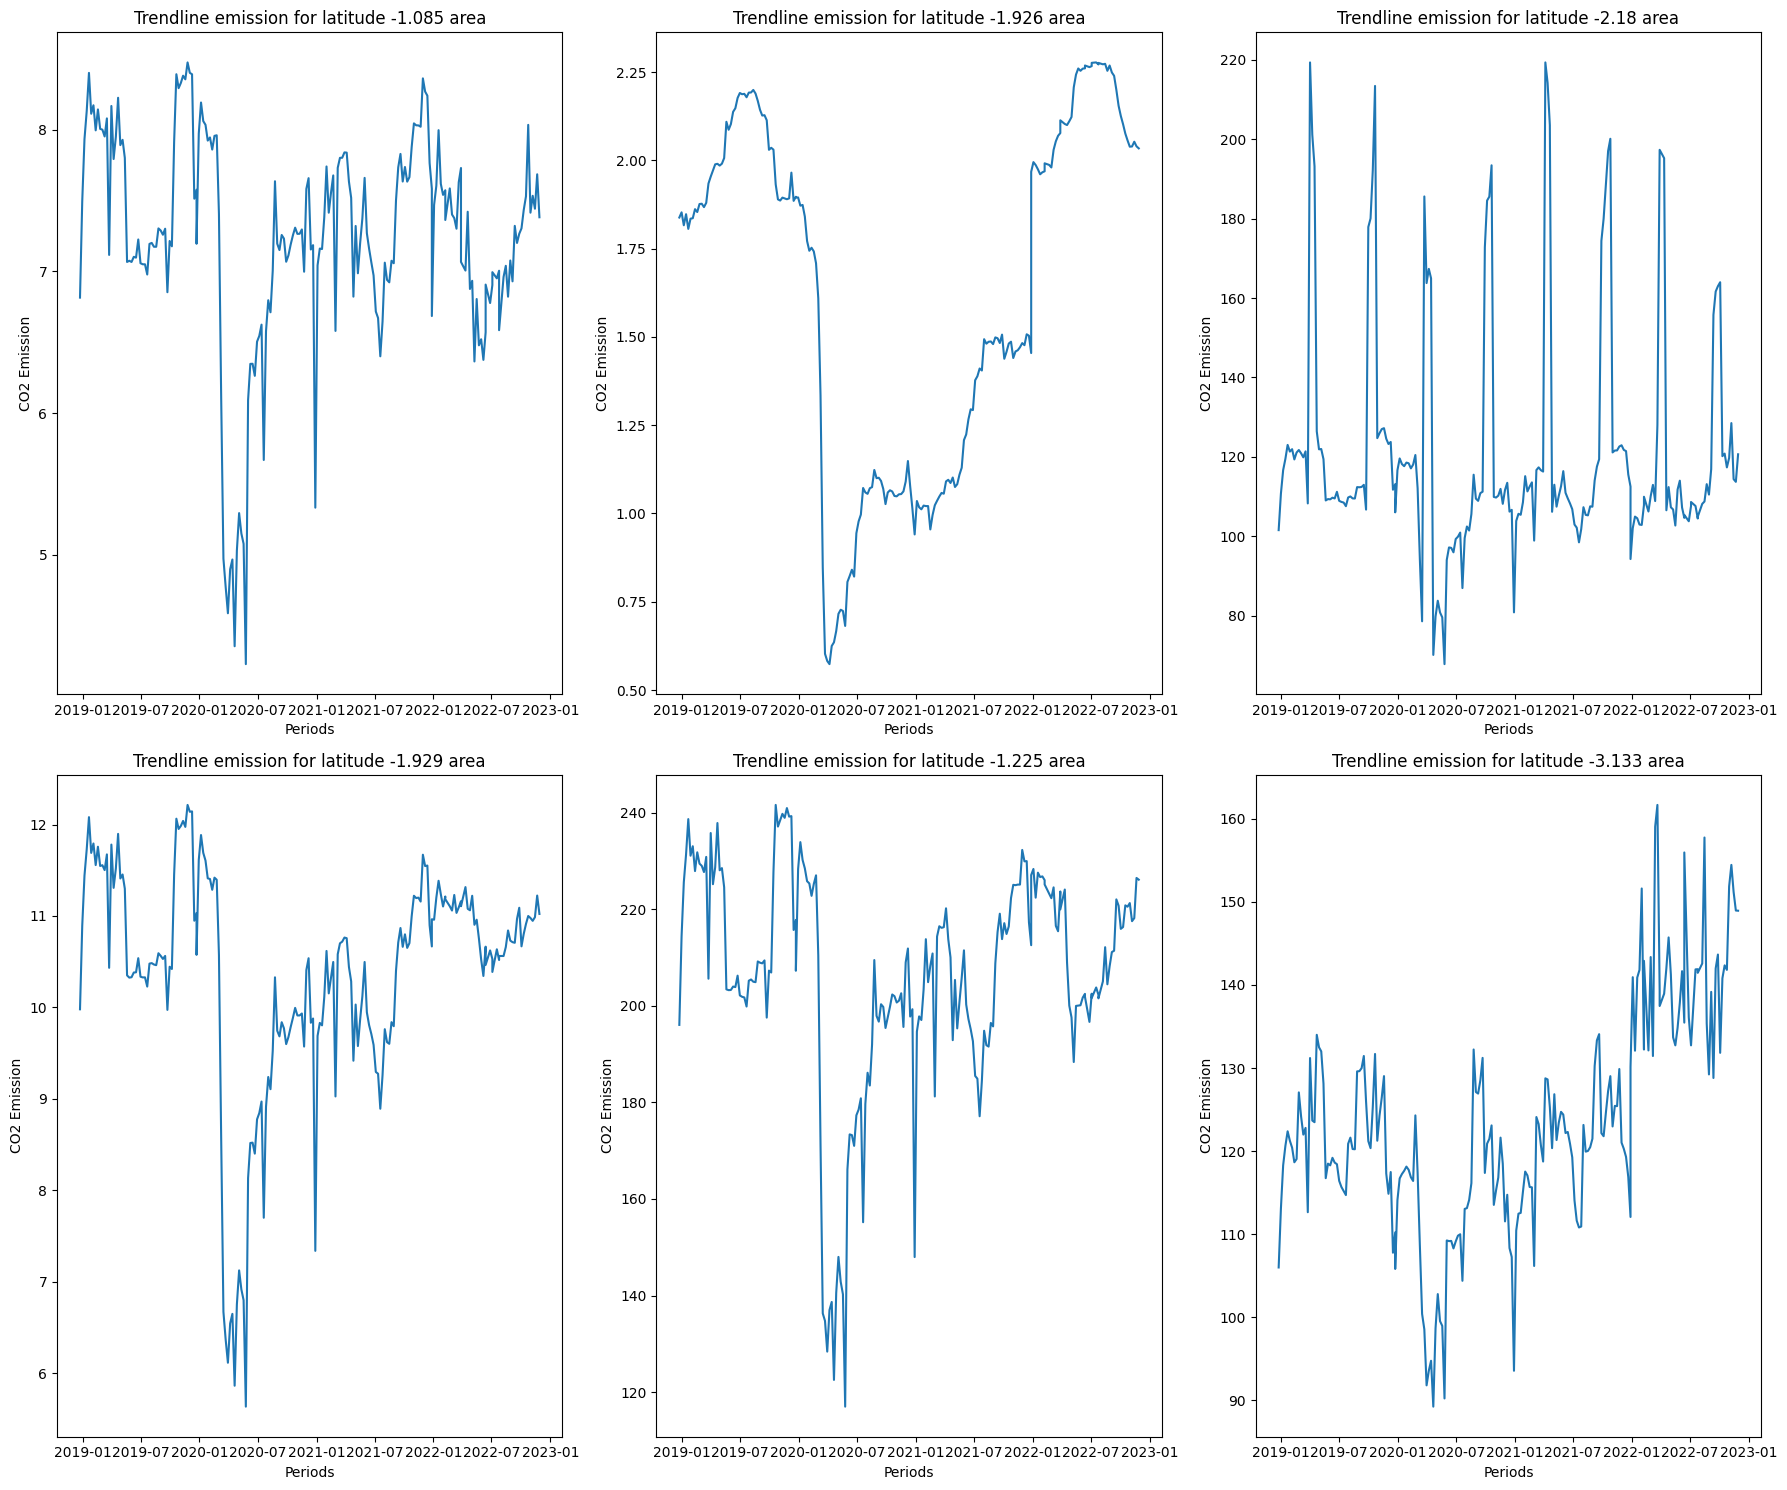

In [66]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(18,15))
plt.subplot(231)
plt.plot(b['date'], b['emission'])
plt.title('Trendline emission for latitude -1.085 area')
plt.xlabel('Periods')
plt.ylabel('CO2 Emission')

plt.subplot(232)
plt.plot(c['date'], c['emission'])
plt.title('Trendline emission for latitude -1.926 area')
plt.xlabel('Periods')
plt.ylabel('CO2 Emission')

plt.subplot(233)
plt.plot(d['date'], d['emission'])
plt.title('Trendline emission for latitude -2.18 area')
plt.xlabel('Periods')
plt.ylabel('CO2 Emission')

plt.subplot(234)
plt.plot(e['date'], e['emission'])
plt.title('Trendline emission for latitude -1.929 area')
plt.xlabel('Periods')
plt.ylabel('CO2 Emission')

plt.subplot(235)
plt.plot(f['date'], f['emission'])
plt.title('Trendline emission for latitude -1.225 area')
plt.xlabel('Periods')
plt.ylabel('CO2 Emission')

plt.subplot(236)
plt.plot(g['date'], g['emission'])
plt.title('Trendline emission for latitude -3.133 area')
plt.xlabel('Periods')
plt.ylabel('CO2 Emission')

plt.tight_layout()
plt.show()


In [81]:
from sklearn.preprocessing import MinMaxScaler

preproc = MinMaxScaler()

test[['EmissionResult']] = preproc.fit_transform(test[['EmissionResult']])
test

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,EmissionResult
0,-0.510,29.290,2022.0,0.0,-0.000017,-140.529848,-0.000001,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000135,0.957096,0.000097,-140.529848,0.240773,0.001270
1,-0.510,29.290,2022.0,1.0,0.000316,-140.529848,0.000157,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000123,0.957096,0.000058,-140.529848,0.293119,0.001310
2,-0.510,29.290,2022.0,2.0,0.000106,-136.908976,0.000053,0.037795,2629.692089,-0.008104,0.036490,-131.658058,0.000277,0.764546,0.000151,-143.602313,0.267130,0.001371
3,-0.510,29.290,2022.0,3.0,0.000243,-152.999440,0.000093,0.039743,1905.403107,-1.279531,0.134641,-152.999440,0.000151,0.935210,0.000078,-148.466265,0.304679,0.001368
4,-0.510,29.290,2022.0,4.0,-0.000184,-135.794754,-0.000077,0.039232,1307.190702,-1.003091,0.125805,-148.414378,0.000273,0.776969,0.000140,-142.256966,0.284221,0.001386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,-3.299,30.301,2022.0,44.0,-0.000461,-123.965439,-0.000171,0.034566,1745.198159,-1.261533,0.198474,-113.995392,0.000246,0.936790,0.000167,-123.965439,0.180046,0.009451
24349,-3.299,30.301,2022.0,45.0,-0.000029,-126.579977,-0.000010,0.038438,1699.572241,-1.289134,0.226918,-115.022250,0.000119,1.099398,0.000081,-126.579977,0.177833,0.009531
24350,-3.299,30.301,2022.0,46.0,-0.000029,-129.194516,-0.000010,0.033042,1655.505823,-1.537933,0.182539,-123.415652,0.000119,1.262006,0.000081,-129.194516,0.219471,0.009388
24351,-3.299,30.301,2022.0,47.0,0.000077,-131.809054,0.000037,0.030662,1689.421079,-1.786733,0.138160,-131.809054,0.000002,1.424614,-0.000063,-131.809054,0.247275,0.009121


In [82]:
test['year'] = 2022
test['week_no'] = test['week_no'].astype(int)
test

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,EmissionResult
0,-0.510,29.290,2022,0,-0.000017,-140.529848,-0.000001,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000135,0.957096,0.000097,-140.529848,0.240773,0.001270
1,-0.510,29.290,2022,1,0.000316,-140.529848,0.000157,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000123,0.957096,0.000058,-140.529848,0.293119,0.001310
2,-0.510,29.290,2022,2,0.000106,-136.908976,0.000053,0.037795,2629.692089,-0.008104,0.036490,-131.658058,0.000277,0.764546,0.000151,-143.602313,0.267130,0.001371
3,-0.510,29.290,2022,3,0.000243,-152.999440,0.000093,0.039743,1905.403107,-1.279531,0.134641,-152.999440,0.000151,0.935210,0.000078,-148.466265,0.304679,0.001368
4,-0.510,29.290,2022,4,-0.000184,-135.794754,-0.000077,0.039232,1307.190702,-1.003091,0.125805,-148.414378,0.000273,0.776969,0.000140,-142.256966,0.284221,0.001386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,-3.299,30.301,2022,44,-0.000461,-123.965439,-0.000171,0.034566,1745.198159,-1.261533,0.198474,-113.995392,0.000246,0.936790,0.000167,-123.965439,0.180046,0.009451
24349,-3.299,30.301,2022,45,-0.000029,-126.579977,-0.000010,0.038438,1699.572241,-1.289134,0.226918,-115.022250,0.000119,1.099398,0.000081,-126.579977,0.177833,0.009531
24350,-3.299,30.301,2022,46,-0.000029,-129.194516,-0.000010,0.033042,1655.505823,-1.537933,0.182539,-123.415652,0.000119,1.262006,0.000081,-129.194516,0.219471,0.009388
24351,-3.299,30.301,2022,47,0.000077,-131.809054,0.000037,0.030662,1689.421079,-1.786733,0.138160,-131.809054,0.000002,1.424614,-0.000063,-131.809054,0.247275,0.009121


In [83]:
test['date'] = pd.to_datetime(test['year'].astype(str) + test['week_no'].astype(str) + '1', format='%G%V%u')
test

,latitude,longitude,year,week_no,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_solar_azimuth_angle,SulphurDioxide_SO2_column_number_density_15km,CarbonMonoxide_CO_column_number_density,CarbonMonoxide_H2O_column_number_density,NitrogenDioxide_absorbing_aerosol_index,NitrogenDioxide_cloud_fraction,NitrogenDioxide_solar_azimuth_angle,Formaldehyde_tropospheric_HCHO_column_number_density,Formaldehyde_tropospheric_HCHO_column_number_density_amf,Formaldehyde_HCHO_slant_column_number_density,Formaldehyde_solar_azimuth_angle,Cloud_surface_albedo,EmissionResult,date
0,-0.510,29.290,2022,0,-0.000017,-140.529848,-0.000001,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000135,0.957096,0.000097,-140.529848,0.240773,0.001270,2021-12-27
1,-0.510,29.290,2022,1,0.000316,-140.529848,0.000157,0.037641,1688.656342,-1.416309,0.036769,-140.529848,0.000123,0.957096,0.000058,-140.529848,0.293119,0.001310,2022-01-03
2,-0.510,29.290,2022,2,0.000106,-136.908976,0.000053,0.037795,2629.692089,-0.008104,0.036490,-131.658058,0.000277,0.764546,0.000151,-143.602313,0.267130,0.001371,2022-01-10
3,-0.510,29.290,2022,3,0.000243,-152.999440,0.000093,0.039743,1905.403107,-1.279531,0.134641,-152.999440,0.000151,0.935210,0.000078,-148.466265,0.304679,0.001368,2022-01-17
4,-0.510,29.290,2022,4,-0.000184,-135.794754,-0.000077,0.039232,1307.190702,-1.003091,0.125805,-148.414378,0.000273,0.776969,0.000140,-142.256966,0.284221,0.001386,2022-01-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,-3.299,30.301,2022,44,-0.000461,-123.965439,-0.000171,0.034566,1745.198159,-1.261533,0.198474,-113.995392,0.000246,0.936790,0.000167,-123.965439,0.180046,0.009451,2022-10-31
24349,-3.299,30.301,2022,45,-0.000029,-126.579977,-0.000010,0.038438,1699.572241,-1.289134,0.226918,-115.022250,0.000119,1.099398,0.000081,-126.579977,0.177833,0.009531,2022-11-07
24350,-3.299,30.301,2022,46,-0.000029,-129.194516,-0.000010,0.033042,1655.505823,-1.537933,0.182539,-123.415652,0.000119,1.262006,0.000081,-129.194516,0.219471,0.009388,2022-11-14
24351,-3.299,30.301,2022,47,0.000077,-131.809054,0.000037,0.030662,1689.421079,-1.786733,0.138160,-131.809054,0.000002,1.424614,-0.000063,-131.809054,0.247275,0.009121,2022-11-21


In [84]:
# Group data by time
grouped = test.groupby('date')

# Prepare heatmap data: list of [ [lat, lon, intensity], ... ] per time step
heat_data = []
time_index = []

for time, group in grouped:
    points = group[['latitude', 'longitude', 'EmissionResult']].values.tolist()
    heat_data.append(points)
    time_index.append(time.strftime('%Y-%m-%d %H:%M:%S'))

# Initialize the map centered around the data
m = folium.Map(location=[test['latitude'].mean(), test['longitude'].mean()])

# Create the timestamped heatmap
HeatMapWithTime(
    data=heat_data,
    index=time_index,
    auto_play=True,
    max_opacity=1.0,
    radius=20
).add_to(m)

m

CONCLUSSION: If we combine the emission from previous year, we can see that in the year 2020, the emission plummets from the previous level in 2019. This drop happens evenly throughout all coordinates. Initial assumption is that this happens due to COVID outbreak situation and lots of activities were suspended. These trends then go upwards again in 2021 and based on ML model prediction, the emission in 2022 will reach the same level as 2019 and even surpass it a little bit.

---
### MODELLING WITH FEW DATA AND SELECTED COORDINATES

This is only experimental session.
Basically in this experiment we split the main data into 2 parts -> emission_1 and emission_2. Emission_2 data only contains 3 coordinates. So, the goal of this experiment is to see whether or not we can just use data from demission_1 table to predict the data outside learned coordinates. The result is the NRMSE reached up to 60%, because the emission_2 data contains coordinates outside it's learned database and therefore having difficulties to 'use' which coordinates inside it's database to predict these 3 new coordinates. Therefore, we can disregard this section.


In [ ]:
spliting = 78546 - (53 * 3 * 4)
spliting


In [ ]:
# emission_1 = emission.loc[emission['latitude'] == -0.51]
emission_1 = emission.iloc[:78546]
emission_1

In [ ]:
emission_1.drop(columns=['year'], inplace=True)
emission_1

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler()
emission_1[emission_1.columns] = scale.fit_transform(emission_1[emission_1.columns])
emission_1

In [ ]:
emission_1.corr()['emission'].sort_values(ascending=False)

In [43]:
y = emission_1['emission']
x = emission_1.drop(columns='emission')

In [44]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.35, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

rff_rg = RandomForestRegressor(n_estimators=150, criterion='squared_error')
rff_rg.fit(x_train, y_train)
y_pred = rff_rg.predict(x_test)
y_pred

In [ ]:
y_test

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

score_rmse = root_mean_squared_error(y_test, y_pred)
score_mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'Score rmse: {score_rmse}')
print(f'Score mape: {score_mape}')

In [ ]:
# from sklearn.model_selection import cross_val_score

# scores = cross_val_score(rff_rg, x_train, y_train,
#                          scoring='neg_mean_absolute_error', cv=5)
# for i in scores:
#     print(f'{-i:.2f}')